# dxf_to_motorcad_region

# Explicit Notebook Cell Labels
- This notebook uses explicit labels `CELL-01`, `CELL-02`, ... inside markdown + code comments.
- Refer to these labels when discussing cells (independent of VS Code UI ordering).

**Run path**: `CELL-01` → `CELL-02` → `CELL-03` (optional `CELL-04`).

In [1]:
# CELL-01: Set DXF path
# dxfPath=r"E:\KDH\KJS\C688\Moasoft C588_CAD.dxf"
dxfPath=r"E:\KDH\MoGen\Inde_propersion_motor.dxf"
dxf_path=dxfPath

In [35]:
# CELL-02: 회전기 DXF 분석 핵심 함수 모음
# 마크다운 요구사항별 함수 구현
# ─────────────────────────────────────────────────────────────
import ezdxf
import math
import numpy as np
from collections import Counter, defaultdict
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
import matplotlib.pyplot as plt
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend


# ═══════════════════════════════════════════════════════════════
# 데이터 클래스: 엔티티 정보를 담는 구조체
# ═══════════════════════════════════════════════════════════════
@dataclass
class EntityInfo:
    """DXF 엔티티 하나의 핵심 정보를 담는 구조체."""
    etype: str               # LINE, ARC, CIRCLE, LWPOLYLINE, ...
    layer: str
    points: List[Tuple[float, float]]   # 대표 좌표들
    radius: Optional[float] = None      # CIRCLE/ARC
    center: Optional[Tuple[float, float]] = None
    start_angle: Optional[float] = None  # ARC (degrees)
    end_angle: Optional[float] = None
    raw: object = field(default=None, repr=False)

    @property
    def r_min(self) -> float:
        """원점에서 가장 가까운 점까지의 거리."""
        return min(math.hypot(x, y) for x, y in self.points) if self.points else float('inf')

    @property
    def r_max(self) -> float:
        """원점에서 가장 먼 점까지의 거리."""
        return max(math.hypot(x, y) for x, y in self.points) if self.points else 0.0

    @property
    def angle_deg(self) -> float:
        """대표 좌표의 평균 각도(deg, 0~360)."""
        if not self.points:
            return 0.0
        angles = [math.degrees(math.atan2(y, x)) % 360 for x, y in self.points]
        return float(np.mean(angles))


# ═══════════════════════════════════════════════════════════════
# 1) 객체 리스트 읽어오기
# ═══════════════════════════════════════════════════════════════
def read_entity_list(dxf_path: str) -> Tuple[List[EntityInfo], ezdxf.document.Drawing]:
    """
    DXF 파일의 modelspace 엔티티를 읽어 EntityInfo 리스트로 반환합니다.
    """
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()
    entities: List[EntityInfo] = []

    for e in msp:
        t = e.dxftype()
        layer = getattr(e.dxf, 'layer', '(no layer)')
        pts = []
        radius = center = sa = ea = None

        if t == 'LINE':
            pts = [(float(e.dxf.start.x), float(e.dxf.start.y)),
                   (float(e.dxf.end.x),   float(e.dxf.end.y))]
        elif t == 'CIRCLE':
            cx, cy = float(e.dxf.center.x), float(e.dxf.center.y)
            r = float(e.dxf.radius)
            center = (cx, cy)
            radius = r
            pts = [(cx + r, cy), (cx - r, cy), (cx, cy + r), (cx, cy - r)]
        elif t == 'ARC':
            cx, cy = float(e.dxf.center.x), float(e.dxf.center.y)
            r = float(e.dxf.radius)
            center = (cx, cy)
            radius = r
            sa = float(e.dxf.start_angle)
            ea = float(e.dxf.end_angle)
            for ang_deg in [sa, ea, (sa + ea) / 2]:
                rad = math.radians(ang_deg)
                pts.append((cx + r * math.cos(rad), cy + r * math.sin(rad)))
        elif t == 'LWPOLYLINE':
            pts = [(float(x), float(y)) for x, y in e.get_points(format='xy')]
        elif t == 'SPLINE':
            try:
                ctrl = list(e.control_points)
                pts = [(float(p[0]), float(p[1])) for p in ctrl]
            except Exception:
                pass
        elif t == 'POINT':
            pts = [(float(e.dxf.location.x), float(e.dxf.location.y))]
        else:
            continue

        if pts:
            entities.append(EntityInfo(
                etype=t, layer=layer, points=pts,
                radius=radius, center=center,
                start_angle=sa, end_angle=ea, raw=e
            ))

    print(f"[read_entity_list] {len(entities)} entities loaded from {dxf_path}")
    layer_cnt = Counter(ei.layer for ei in entities)
    for name, cnt in layer_cnt.most_common(20):
        print(f"  {name:30s}  {cnt}")
    return entities, doc


# ═══════════════════════════════════════════════════════════════
# 2) 원점 확인 (회전기 대상)
# ═══════════════════════════════════════════════════════════════
def find_origin_candidates(doc, entities, plot=True):
    """DXF 헤더 + 엔티티 기반으로 원점 후보를 반환합니다."""
    def _hdr_pt(name):
        v = doc.header.get(name, None)
        if v is None:
            return None
        try:
            return (float(v[0]), float(v[1]))
        except Exception:
            try:
                return (float(v.x), float(v.y))
            except Exception:
                return None

    insbase = _hdr_pt('$INSBASE')
    ucsorg  = _hdr_pt('$UCSORG')
    pucsorg = _hdr_pt('$PUCSORG')
    extmin  = _hdr_pt('$EXTMIN')
    extmax  = _hdr_pt('$EXTMAX')
    ext_center = None
    if extmin and extmax:
        ext_center = ((extmin[0]+extmax[0])/2, (extmin[1]+extmax[1])/2)

    all_pts = [p for ei in entities for p in ei.points]
    if all_pts:
        xs, ys = zip(*all_pts)
        bbox = ((min(xs), min(ys)), (max(xs), max(ys)))
        bbox_center = ((bbox[0][0]+bbox[1][0])/2, (bbox[0][1]+bbox[1][1])/2)
    else:
        bbox = bbox_center = None

    circles_at_origin = [ei for ei in entities
                         if ei.etype=='CIRCLE' and ei.center
                         and math.hypot(ei.center[0], ei.center[1]) < 1e-3]
    circles_at_bbox = []
    if bbox_center:
        circles_at_bbox = [ei for ei in entities
                           if ei.etype=='CIRCLE' and ei.center
                           and math.hypot(ei.center[0]-bbox_center[0],
                                          ei.center[1]-bbox_center[1]) < 1e-3]

    best_origin = (0.0, 0.0) if len(circles_at_origin) >= len(circles_at_bbox) else bbox_center

    result = {'wcs': (0.0,0.0), 'insbase': insbase, 'ucsorg': ucsorg,
              'pucsorg': pucsorg, 'ext_center': ext_center,
              'bbox': bbox, 'bbox_center': bbox_center, 'best_origin': best_origin}

    print('[find_origin_candidates]')
    for k, v in result.items():
        print(f'  {k:15s}: {v}')

    if plot:
        fig, ax = plt.subplots(figsize=(9,9))
        ctx = RenderContext(doc)
        out = MatplotlibBackend(ax)
        Frontend(ctx, out).draw_layout(doc.modelspace(), finalize=True)
        ax.axhline(0, color='red', lw=0.8); ax.axvline(0, color='red', lw=0.8)
        ax.plot(0, 0, 'ro', ms=5, label='WCS(0,0)')
        if bbox_center:
            ax.plot(*bbox_center, 'kx', ms=10, label='bbox center')
        ax.plot(*best_origin, 'g*', ms=14, label=f'best_origin')
        ax.set_aspect('equal'); ax.legend(); ax.grid(True, lw=0.3)
        plt.show()
    return result


# ═══════════════════════════════════════════════════════════════
# 3) 외전형(Outer Rotor) / 내전형(Inner Rotor) 구분
# ═══════════════════════════════════════════════════════════════
def classify_inner_outer_rotor(entities, origin=(0.0, 0.0)):
    """동심원 에어갭 기준으로 외전형/내전형을 판별합니다."""
    ox, oy = origin
    concentric = []
    for ei in entities:
        if ei.etype in ('CIRCLE', 'ARC') and ei.center:
            d = math.hypot(ei.center[0]-ox, ei.center[1]-oy)
            if d < 1e-3 and ei.radius:
                concentric.append(ei.radius)
    if len(concentric) < 2:
        print('[classify_inner_outer_rotor] 동심원 부족 → unknown')
        return 'unknown'

    concentric = sorted(set(round(r, 4) for r in concentric))
    print(f'[classify_inner_outer_rotor] concentric radii ({len(concentric)}): {concentric}')

    gaps = [(concentric[i+1]-concentric[i], i) for i in range(len(concentric)-1)]
    min_gap, gap_idx = min(gaps, key=lambda x: x[0])
    r_inner = concentric[gap_idx]
    r_outer = concentric[gap_idx+1]

    inner_entities = [ei for ei in entities if ei.r_max < (r_inner+r_outer)/2]
    outer_entities = [ei for ei in entities if ei.r_min > (r_inner+r_outer)/2]

    print(f'  airgap: r_inner={r_inner:.4f}, r_outer={r_outer:.4f}, gap={min_gap:.4f}')
    print(f'  inner entities: {len(inner_entities)},  outer entities: {len(outer_entities)}')

    result = 'inner_rotor' if len(outer_entities) >= len(inner_entities) else 'outer_rotor'
    print(f'  → 판별 결과: {result}')
    return result


# ═══════════════════════════════════════════════════════════════
# 4) 고정자 / 회전자 구분
# ═══════════════════════════════════════════════════════════════
@dataclass
class StatorRotorSplit:
    """고정자/회전자 분리 결과."""
    airgap_r_inner: float
    airgap_r_outer: float
    stator_entities: List[EntityInfo]
    rotor_entities: List[EntityInfo]
    motor_type: str


def split_stator_rotor(entities, origin=(0.0, 0.0), motor_type=None):
    """에어갭 기준으로 엔티티를 고정자/회전자로 분류합니다."""
    ox, oy = origin
    if motor_type is None:
        motor_type = classify_inner_outer_rotor(entities, origin)

    concentric = []
    for ei in entities:
        if ei.etype in ('CIRCLE', 'ARC') and ei.center:
            d = math.hypot(ei.center[0]-ox, ei.center[1]-oy)
            if d < 1e-3 and ei.radius:
                concentric.append(ei.radius)

    concentric = sorted(set(round(r, 4) for r in concentric))
    gaps = [(concentric[i+1]-concentric[i], i) for i in range(len(concentric)-1)]
    min_gap, gap_idx = min(gaps, key=lambda x: x[0])
    r_inner = concentric[gap_idx]
    r_outer = concentric[gap_idx+1]
    r_mid = (r_inner + r_outer) / 2

    inner_ents = [ei for ei in entities if ei.r_max <= r_mid]
    outer_ents = [ei for ei in entities if ei.r_min >= r_mid]
    for ei in entities:
        if ei not in inner_ents and ei not in outer_ents:
            if ei.r_min < r_mid:
                inner_ents.append(ei)
            else:
                outer_ents.append(ei)

    if motor_type == 'inner_rotor':
        stator_ents, rotor_ents = outer_ents, inner_ents
    else:
        stator_ents, rotor_ents = inner_ents, outer_ents

    print(f'[split_stator_rotor] motor_type={motor_type}')
    print(f'  airgap: {r_inner:.4f} ~ {r_outer:.4f}')
    print(f'  stator entities: {len(stator_ents)},  rotor entities: {len(rotor_ents)}')
    return StatorRotorSplit(
        airgap_r_inner=r_inner, airgap_r_outer=r_outer,
        stator_entities=stator_ents, rotor_entities=rotor_ents,
        motor_type=motor_type
    )


# ═══════════════════════════════════════════════════════════════
# 5-a) 동일한 형태의 객체 판별 → 리스트화
# ═══════════════════════════════════════════════════════════════
def _entity_signature(ei, origin=(0.0, 0.0)):
    """엔티티의 '형태 시그니처' (종류+크기 양자화)."""
    if ei.etype == 'CIRCLE' and ei.radius:
        return f"CIRCLE_r{ei.radius:.3f}"
    elif ei.etype == 'ARC' and ei.radius:
        span = (ei.end_angle - ei.start_angle) % 360
        return f"ARC_r{ei.radius:.3f}_span{span:.1f}"
    elif ei.etype == 'LINE':
        dx = ei.points[1][0] - ei.points[0][0]
        dy = ei.points[1][1] - ei.points[0][1]
        length = math.hypot(dx, dy)
        r_avg = (ei.r_min + ei.r_max) / 2
        return f"LINE_len{length:.3f}_ravg{r_avg:.2f}"
    elif ei.etype == 'LWPOLYLINE':
        n = len(ei.points)
        r_avg = (ei.r_min + ei.r_max) / 2
        return f"POLY_n{n}_ravg{r_avg:.2f}"
    else:
        return f"{ei.etype}_ravg{(ei.r_min + ei.r_max) / 2:.2f}"


def group_identical_entities(entities, origin=(0.0, 0.0)):
    """동일 형태(시그니처)의 엔티티를 그룹핑합니다."""
    groups = defaultdict(list)
    for ei in entities:
        sig = _entity_signature(ei, origin)
        groups[sig].append(ei)

    print(f'[group_identical_entities] {len(groups)} distinct shapes')
    for sig, grp in sorted(groups.items(), key=lambda x: -len(x[1])):
        if len(grp) >= 2:
            print(f'  {sig:45s}  x{len(grp)}')
    return dict(groups)


# ═══════════════════════════════════════════════════════════════
# 5-b) Circular pattern vs Mirror 대칭 구분
# ═══════════════════════════════════════════════════════════════
def _entity_angle(ei, origin=(0.0, 0.0)):
    """엔티티의 대표 각도(deg, 0~360) — 원점 기준."""
    ox, oy = origin
    if ei.center and ei.etype in ('ARC', 'CIRCLE'):
        return math.degrees(math.atan2(ei.center[1]-oy, ei.center[0]-ox)) % 360
    if ei.points:
        mx = np.mean([p[0] for p in ei.points]) - ox
        my = np.mean([p[1] for p in ei.points]) - oy
        return math.degrees(math.atan2(my, mx)) % 360
    return 0.0


def detect_mirror_pairs(group, origin=(0.0, 0.0), angle_tol=0.5):
    """
    동일 시그니처 그룹 내에서 mirror 쌍을 탐지합니다.

    원리:
      같은 형태의 엔티티 N개가 원형 배치되어 있을 때,
      인접한 두 엔티티 사이의 각도 간격(angular step)이
      교대로 '좁은-넓은' 패턴이면 → 한 극/슬롯 내에서
      기준선에 대해 mirror된 쌍이 존재.

      예) 16개 LINE이 있고 angular step이
          [a, b, a, b, ...] 식으로 교대 →
          실제 circular pattern 개수 = 16/2 = 8

    Returns
    -------
    dict: has_mirror, mirror_axis_angles, circular_count, raw_count
    """
    n = len(group)
    if n < 4:
        return {'has_mirror': False, 'mirror_axis_angles': [],
                'circular_count': n, 'raw_count': n}

    # 각도 정렬
    angles = sorted([_entity_angle(ei, origin) for ei in group])

    # 인접 각도 간격 (wrap-around 포함)
    steps = np.array([(angles[(i+1) % n] - angles[i]) % 360 for i in range(n)])

    # --- Case 1: 교대 패턴 (a, b, a, b, ...) ---
    if n % 2 == 0:
        even_steps = steps[0::2]
        odd_steps  = steps[1::2]
        even_std  = float(np.std(even_steps))
        odd_std   = float(np.std(odd_steps))
        even_mean = float(np.mean(even_steps))
        odd_mean  = float(np.mean(odd_steps))

        both_tight = even_std < angle_tol and odd_std < angle_tol
        means_differ = abs(even_mean - odd_mean) > angle_tol

        if both_tight and means_differ:
            mirror_axes = [((angles[i] + angles[(i+1) % n]) / 2) % 360
                           for i in range(0, n, 2)]
            return {
                'has_mirror': True,
                'mirror_axis_angles': mirror_axes,
                'circular_count': n // 2,
                'raw_count': n,
                'pattern': 'alternating_step',
                'step_even_mean': round(even_mean, 3),
                'step_odd_mean': round(odd_mean, 3),
            }

    # --- Case 2: 균등 간격 (순수 circular) ---
    uniform_std = float(np.std(steps))
    if uniform_std < angle_tol:
        return {'has_mirror': False, 'mirror_axis_angles': [],
                'circular_count': n, 'raw_count': n,
                'pattern': 'uniform_circular',
                'step_mean': round(float(np.mean(steps)), 3)}

    # --- Case 3: 인접 쌍 (0-1, 2-3, ...) mirror ---
    if n % 2 == 0:
        pair_spans = [(angles[2*i+1] - angles[2*i]) % 360 for i in range(n//2)]
        pair_gaps  = [(angles[2*((i+1) % (n//2))] - angles[2*i+1]) % 360
                      for i in range(n//2)]
        ps_std = float(np.std(pair_spans))
        pg_std = float(np.std(pair_gaps))
        if ps_std < angle_tol and pg_std < angle_tol:
            mirror_axes = [((angles[2*i] + angles[2*i+1]) / 2) % 360
                           for i in range(n//2)]
            return {
                'has_mirror': True,
                'mirror_axis_angles': mirror_axes,
                'circular_count': n // 2,
                'raw_count': n,
                'pattern': 'paired_mirror',
            }

    return {'has_mirror': False, 'mirror_axis_angles': [],
            'circular_count': n, 'raw_count': n,
            'pattern': 'irregular'}


def classify_group_patterns(entities, origin=(0.0, 0.0)):
    """
    group_identical_entities 결과에 대해
    각 그룹이 circular pattern인지 mirror+circular인지 분류합니다.
    """
    groups = group_identical_entities(entities, origin)
    result = {}
    print(f'\n[classify_group_patterns] mirror/circular 분석:')
    for sig, grp in sorted(groups.items(), key=lambda x: -len(x[1])):
        if len(grp) < 2:
            result[sig] = {'entities': grp, 'has_mirror': False,
                           'circular_count': len(grp), 'raw_count': len(grp)}
            continue
        minfo = detect_mirror_pairs(grp, origin)
        minfo['entities'] = grp
        result[sig] = minfo
        tag = '🪞 MIRROR' if minfo['has_mirror'] else '🔄 CIRCULAR'
        print(f'  {sig:45s}  x{len(grp):3d} → {tag}  '
              f'circular_count={minfo["circular_count"]}')
    return result


# ═══════════════════════════════════════════════════════════════
# 6) 360도 전체 모델 vs 주기 모델 판별
# ═══════════════════════════════════════════════════════════════
def detect_model_periodicity(entities, origin=(0.0, 0.0)):
    """엔티티의 각도 분포로 360° 전체 모델인지 주기 모델인지 판별합니다."""
    ox, oy = origin
    angles = []
    for ei in entities:
        for x, y in ei.points:
            r = math.hypot(x-ox, y-oy)
            if r > 1e-6:
                a = math.degrees(math.atan2(y-oy, x-ox)) % 360
                angles.append(a)

    if not angles:
        return {'period_deg': 360, 'n_periods': 1, 'is_full_model': True, 'angular_span': 0}

    angles = np.array(angles)
    ang_min, ang_max = float(np.min(angles)), float(np.max(angles))
    span = ang_max - ang_min
    is_full = span > 350.0

    groups = group_identical_entities(entities, origin)
    counts = [len(v) for v in groups.values() if len(v) >= 2]

    if is_full and counts:
        from math import gcd
        from functools import reduce
        g = reduce(gcd, counts)
        period_deg = 360.0 / g
        n_periods = g
    elif not is_full:
        period_deg = span
        n_periods = round(360.0 / span) if span > 1 else 1
    else:
        period_deg = 360.0
        n_periods = 1

    result = {
        'period_deg': round(period_deg, 2),
        'n_periods': n_periods,
        'is_full_model': is_full,
        'angular_span': round(span, 2),
    }
    print(f'[detect_model_periodicity] {result}')
    return result


# ═══════════════════════════════════════════════════════════════
# 7) 극수 / 슬롯수 추론 (mirror 보정 포함)
# ═══════════════════════════════════════════════════════════════
def infer_poles_and_slots(split, periodicity, origin=(0.0, 0.0)):
    """
    고정자/회전자 엔티티의 반복 패턴으로 극수·슬롯수를 추론합니다.
    mirror 대칭을 고려하여 실제 circular 반복 수를 사용합니다.

    핵심 로직:
      - 한 극/슬롯 내에서 기준선 대칭(mirror)인 엔티티 쌍이 있으면
        raw_count를 2로 나눈 circular_count가 실제 극수/슬롯수.
      - 순수 circular pattern이면 raw_count 그대로 사용.
    """
    print('\n--- Rotor ---')
    rotor_patterns = classify_group_patterns(split.rotor_entities, origin)
    print('\n--- Stator ---')
    stator_patterns = classify_group_patterns(split.stator_entities, origin)

    def _best_count(patterns):
        """
        mirror 그룹이 있으면 mirror 그룹의 circular_count 중 최빈값을 사용.
        mirror 그룹이 없으면 전체 circular_count 중 최빈값을 사용.
        이렇게 해야 순수 circular인 ARC/CIRCLE의 큰 count에 끌려가지 않음.
        """
        mirror_cc = [info['circular_count'] for info in patterns.values()
                     if info['raw_count'] >= 2 and info.get('has_mirror', False)]
        all_cc    = [info['circular_count'] for info in patterns.values()
                     if info['raw_count'] >= 2]

        if mirror_cc:
            # mirror 그룹의 circular_count 중 최빈값 (가장 많이 등장하는 값)
            cnt = Counter(mirror_cc)
            return cnt.most_common(1)[0][0]
        elif all_cc:
            cnt = Counter(all_cc)
            return cnt.most_common(1)[0][0]
        return 0

    def _top_raw_count(patterns):
        rc = sorted([info['raw_count'] for info in patterns.values()
                     if info['raw_count'] >= 2], reverse=True)
        return rc[0] if rc else 0

    rotor_circ  = _best_count(rotor_patterns)
    rotor_raw   = _top_raw_count(rotor_patterns)
    stator_circ = _best_count(stator_patterns)
    stator_raw  = _top_raw_count(stator_patterns)

    # 주기 모델이면 전체 모델로 환산
    if not periodicity['is_full_model']:
        scale = periodicity['n_periods']
        rotor_circ  *= scale
        rotor_raw   *= scale
        stator_circ *= scale
        stator_raw  *= scale

    # 극수: mirror 보정값 사용, 짝수 확인
    n_poles = rotor_circ
    if n_poles % 2 != 0 and n_poles > 1:
        if rotor_raw % 2 == 0:
            n_poles = rotor_raw

    n_slots = stator_circ

    rotor_has_mirror  = any(info.get('has_mirror', False) for info in rotor_patterns.values())
    stator_has_mirror = any(info.get('has_mirror', False) for info in stator_patterns.values())

    result = {
        'n_poles': n_poles,
        'n_slots': n_slots,
        'rotor_repeats_raw': rotor_raw,
        'rotor_repeats_circular': rotor_circ,
        'stator_repeats_raw': stator_raw,
        'stator_repeats_circular': stator_circ,
        'rotor_has_mirror': rotor_has_mirror,
        'stator_has_mirror': stator_has_mirror,
    }
    print(f'\n[infer_poles_and_slots] 결과:')
    print(f'  Rotor:  raw={rotor_raw}, circular(mirror보정)={rotor_circ}, '
          f'has_mirror={rotor_has_mirror}')
    print(f'  Stator: raw={stator_raw}, circular(mirror보정)={stator_circ}, '
          f'has_mirror={stator_has_mirror}')
    print(f'  → n_poles={n_poles}, n_slots={n_slots}')
    return result


# ═══════════════════════════════════════════════════════════════
# 8) Closed Region 가능성 검증
# ═══════════════════════════════════════════════════════════════
def check_closed_regions(entities, n_poles, n_slots, periodicity):
    """Closed region 생성 가능 여부를 판별합니다."""
    groups = group_identical_entities(entities)
    counts = [len(v) for v in groups.values() if len(v) >= 2]

    pole_multiples = [c for c in counts if n_poles > 0 and c % n_poles == 0]
    slot_multiples = [c for c in counts if n_slots > 0 and c % n_slots == 0]
    can_close = len(pole_multiples) > 0 or len(slot_multiples) > 0

    symmetry_ok = True
    issues = []
    if periodicity['is_full_model']:
        if n_poles > 0 and n_poles % 2 != 0:
            issues.append(f'극수({n_poles})가 홀수')
            symmetry_ok = False
        if n_slots > 0 and n_slots % 2 != 0:
            issues.append(f'슬롯수({n_slots})가 홀수')

    result = {
        'can_close_region': can_close,
        'pole_multiple_groups': len(pole_multiples),
        'slot_multiple_groups': len(slot_multiples),
        'symmetry_ok': symmetry_ok,
        'issues': issues,
    }
    print(f'[check_closed_regions] {result}')
    return result


# ═══════════════════════════════════════════════════════════════
# 9) 대칭 깨짐 식별 & 한 주기 추출
# ═══════════════════════════════════════════════════════════════
def identify_symmetry_break(entities, period_deg, origin=(0.0, 0.0), angle_tol=1.0):
    """섹터별 엔티티 수를 비교하여 대칭 깨짐을 식별합니다."""
    ox, oy = origin
    n_sectors = max(1, round(360.0 / period_deg))
    sector_counts = Counter()
    sector_entities = defaultdict(list)

    for ei in entities:
        a = ei.angle_deg
        if ei.center:
            a = math.degrees(math.atan2(ei.center[1]-oy, ei.center[0]-ox)) % 360
        sector_idx = int(a // period_deg) % n_sectors
        sector_counts[sector_idx] += 1
        sector_entities[sector_idx].append(ei)

    if not sector_counts:
        return {'broken_sectors': [], 'sector_counts': {}, 'reference_sector': 0}

    ref_sector = sector_counts.most_common(1)[0][0]
    ref_count = sector_counts[ref_sector]

    broken = []
    for s in range(n_sectors):
        c = sector_counts.get(s, 0)
        if abs(c - ref_count) > 1:
            broken.append({'sector': s, 'angle_start': s*period_deg,
                           'angle_end': (s+1)*period_deg,
                           'count': c, 'expected': ref_count})

    result = {
        'broken_sectors': broken,
        'sector_counts': dict(sector_counts),
        'reference_sector': ref_sector,
        'n_sectors': n_sectors,
    }
    print(f'[identify_symmetry_break] {len(broken)} broken sectors out of {n_sectors}')
    if broken:
        for b in broken:
            print(f'  sector {b["sector"]}: {b["angle_start"]:.1f}°~{b["angle_end"]:.1f}° '
                  f'count={b["count"]} (expected {b["expected"]})')
    return result


def extract_one_period(entities, period_deg, reference_sector=0, origin=(0.0, 0.0)):
    """한 주기(reference_sector)에 해당하는 엔티티만 추출합니다."""
    ox, oy = origin
    ang_start = reference_sector * period_deg
    ang_end = ang_start + period_deg

    one_period = []
    for ei in entities:
        a = ei.angle_deg
        if ei.center:
            a = math.degrees(math.atan2(ei.center[1]-oy, ei.center[0]-ox)) % 360
        if ei.etype == 'CIRCLE' and ei.center:
            d = math.hypot(ei.center[0]-ox, ei.center[1]-oy)
            if d < 1e-3:
                one_period.append(ei)
                continue
        if ang_start <= a < ang_end:
            one_period.append(ei)

    print(f'[extract_one_period] sector {reference_sector} '
          f'({ang_start:.1f}°~{ang_end:.1f}°): {len(one_period)} entities')
    return one_period


# ═══════════════════════════════════════════════════════════════
# 10) 최소 반복 단위(반슬롯/반극) 추출 & 재구성 그리기
# ═══════════════════════════════════════════════════════════════

def _rotate_point(x, y, angle_rad, ox=0.0, oy=0.0):
    """점 (x,y)를 원점 (ox,oy) 기준으로 angle_rad만큼 회전."""
    dx, dy = x - ox, y - oy
    cos_a, sin_a = math.cos(angle_rad), math.sin(angle_rad)
    return (ox + dx * cos_a - dy * sin_a,
            oy + dx * sin_a + dy * cos_a)


def _mirror_point(x, y, axis_angle_rad, ox=0.0, oy=0.0):
    """점 (x,y)를 원점 (ox,oy)을 지나는 axis_angle_rad 각도 직선에 대해 대칭."""
    dx, dy = x - ox, y - oy
    cos2a = math.cos(2 * axis_angle_rad)
    sin2a = math.sin(2 * axis_angle_rad)
    mx = ox + dx * cos2a + dy * sin2a
    my = oy + dx * sin2a - dy * cos2a
    return (mx, my)


def _transform_entity(ei, transform_fn):
    """
    EntityInfo를 좌표 변환 함수(transform_fn)로 변환한 새 EntityInfo를 반환.
    transform_fn: (x, y) -> (x', y')
    """
    new_points = [transform_fn(p[0], p[1]) for p in ei.points]
    new_center = transform_fn(*ei.center) if ei.center else None
    new_sa = ei.start_angle
    new_ea = ei.end_angle

    # ARC/CIRCLE의 각도도 변환해야 함
    if ei.etype == 'ARC' and ei.center and ei.radius:
        # 시작/끝점 변환 후 각도 재계산
        cx, cy = new_center
        r = ei.radius
        # 원래 시작/끝점
        sa_rad = math.radians(ei.start_angle)
        ea_rad = math.radians(ei.end_angle)
        p_start = transform_fn(ei.center[0] + r * math.cos(sa_rad),
                               ei.center[1] + r * math.sin(sa_rad))
        p_end   = transform_fn(ei.center[0] + r * math.cos(ea_rad),
                               ei.center[1] + r * math.sin(ea_rad))
        new_sa = math.degrees(math.atan2(p_start[1] - cy, p_start[0] - cx)) % 360
        new_ea = math.degrees(math.atan2(p_end[1] - cy, p_end[0] - cx)) % 360

    return EntityInfo(
        etype=ei.etype,
        layer=ei.layer,
        points=new_points,
        radius=ei.radius,
        center=new_center,
        start_angle=new_sa,
        end_angle=new_ea,
        raw=None,
    )


def _rotate_entity(ei, angle_deg, origin=(0.0, 0.0)):
    """EntityInfo를 angle_deg만큼 회전."""
    ox, oy = origin
    rad = math.radians(angle_deg)
    return _transform_entity(ei, lambda x, y: _rotate_point(x, y, rad, ox, oy))


def _mirror_entity(ei, axis_angle_deg, origin=(0.0, 0.0)):
    """EntityInfo를 원점을 지나는 axis_angle_deg 직선에 대해 대칭."""
    ox, oy = origin
    rad = math.radians(axis_angle_deg)
    mirrored = _transform_entity(ei, lambda x, y: _mirror_point(x, y, rad, ox, oy))

    # ARC의 경우 미러링하면 방향이 반전됨 (start/end 교환)
    if mirrored.etype == 'ARC' and mirrored.start_angle is not None:
        mirrored.start_angle, mirrored.end_angle = mirrored.end_angle, mirrored.start_angle
        # 점 순서도 반전
        mirrored.points = list(reversed(mirrored.points))

    return mirrored


def extract_half_unit(entities, split, poles_slots, periodicity,
                      origin=(0.0, 0.0)):
    """
    최소 반복 단위(반슬롯 고정자 + 반극 회전자)를 추출합니다.

    원리:
      - mirror 대칭이 있으면 → 한 슬롯/극의 절반만이 최소 단위
      - 고정자: 반슬롯 피치 = 360° / (2 * n_slots)
      - 회전자: 반극 피치 = 360° / (2 * n_poles)
      - 동심원(원점 중심 CIRCLE/ARC)은 공통 경계로 별도 분리

    Parameters
    ----------
    entities : list[EntityInfo]
    split : StatorRotorSplit
    poles_slots : dict (from infer_poles_and_slots)
    periodicity : dict
    origin : tuple

    Returns
    -------
    dict with keys:
      half_slot_stator : list[EntityInfo]  (반슬롯 고정자 엔티티)
      half_pole_rotor  : list[EntityInfo]  (반극 회전자 엔티티)
      concentric_circles : list[EntityInfo]  (동심원 경계)
      half_slot_deg : float  (반슬롯 피치 각도)
      half_pole_deg : float  (반극 피치 각도)
      slot_pitch_deg : float
      pole_pitch_deg : float
      ref_angle_start : float  (추출 시작 각도)
    """
    ox, oy = origin
    n_poles = poles_slots['n_poles']
    n_slots = poles_slots['n_slots']

    slot_pitch = 360.0 / n_slots if n_slots > 0 else 10.0
    pole_pitch = 360.0 / n_poles if n_poles > 0 else 45.0
    half_slot = slot_pitch / 2.0
    half_pole = pole_pitch / 2.0

    # reference_sector의 시작 각도 (symmetry break 고려)
    sym = identify_symmetry_break(entities, periodicity['period_deg'], origin)
    ref_sector = sym['reference_sector']
    ref_start = ref_sector * periodicity['period_deg']

    # ── 동심원 분리 ──
    concentric = []
    stator_non_conc = []
    rotor_non_conc = []

    for ei in split.stator_entities:
        if (ei.etype in ('CIRCLE', 'ARC') and ei.center
                and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3):
            concentric.append(ei)
        else:
            stator_non_conc.append(ei)

    for ei in split.rotor_entities:
        if (ei.etype in ('CIRCLE', 'ARC') and ei.center
                and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3):
            concentric.append(ei)
        else:
            rotor_non_conc.append(ei)

    # ── 반슬롯 고정자 추출 ──
    ang_s = ref_start
    ang_e = ref_start + half_slot

    def _in_sector(ei, a_start, a_end):
        """엔티티의 대표 각도가 [a_start, a_end) 범위 안인지."""
        a = _entity_angle(ei, origin)
        # wrap-around 처리
        a_s = a_start % 360
        a_e = a_end % 360
        if a_s < a_e:
            return a_s <= a < a_e
        else:
            return a >= a_s or a < a_e

    half_slot_stator = [ei for ei in stator_non_conc if _in_sector(ei, ang_s, ang_e)]

    # ── 반극 회전자 추출 ──
    half_pole_rotor = [ei for ei in rotor_non_conc if _in_sector(ei, ang_s, ang_s + half_pole)]

    # 동심원 중복 제거 (같은 반지름은 하나만)
    seen_r = set()
    unique_conc = []
    for ei in concentric:
        r_key = round(ei.radius, 2) if ei.radius else 0
        if r_key not in seen_r:
            seen_r.add(r_key)
            unique_conc.append(ei)

    result = {
        'half_slot_stator': half_slot_stator,
        'half_pole_rotor': half_pole_rotor,
        'concentric_circles': unique_conc,
        'half_slot_deg': half_slot,
        'half_pole_deg': half_pole,
        'slot_pitch_deg': slot_pitch,
        'pole_pitch_deg': pole_pitch,
        'ref_angle_start': ref_start,
    }
    print(f'[extract_half_unit]')
    print(f'  slot_pitch={slot_pitch:.2f}°, half_slot={half_slot:.2f}°')
    print(f'  pole_pitch={pole_pitch:.2f}°, half_pole={half_pole:.2f}°')
    print(f'  half_slot_stator: {len(half_slot_stator)} entities')
    print(f'  half_pole_rotor:  {len(half_pole_rotor)} entities')
    print(f'  concentric:       {len(unique_conc)} circles')
    return result


def reconstruct_geometry(half_unit, origin=(0.0, 0.0),
                         coverage='period', n_poles=None, n_slots=None,
                         period_deg=None):
    """
    반슬롯/반극 최소 단위에서 mirror + circular pattern으로
    원하는 범위의 기하를 재구성합니다.

    Parameters
    ----------
    half_unit : dict (from extract_half_unit)
    origin : tuple
    coverage : 'period' | 'full' | float (원하는 각도 범위, 도)
    n_poles, n_slots : int (전체 극수/슬롯수)
    period_deg : float (한 주기 각도)

    Returns
    -------
    list[EntityInfo] : 재구성된 전체 엔티티 리스트
    """
    half_slot_deg = half_unit['half_slot_deg']
    half_pole_deg = half_unit['half_pole_deg']
    slot_pitch    = half_unit['slot_pitch_deg']
    pole_pitch    = half_unit['pole_pitch_deg']
    ref_start     = half_unit['ref_angle_start']

    # 커버리지 결정
    if coverage == 'full':
        target_deg = 360.0
    elif coverage == 'period':
        target_deg = period_deg if period_deg else 90.0
    else:
        target_deg = float(coverage)

    n_slots_to_build = max(1, round(target_deg / slot_pitch))
    n_poles_to_build = max(1, round(target_deg / pole_pitch))

    result_entities = []

    # ── 1) 고정자: 반슬롯 → mirror → 1슬롯 → circular pattern ──
    half_s = half_unit['half_slot_stator']
    mirror_axis = ref_start + half_slot_deg  # 반슬롯 끝 = 대칭축

    # 1슬롯 = 원본(반슬롯) + mirror(반슬롯)
    one_slot = list(half_s)
    for ei in half_s:
        mirrored = _mirror_entity(ei, mirror_axis, origin)
        one_slot.append(mirrored)

    # n_slots_to_build개 슬롯 circular pattern
    for i in range(n_slots_to_build):
        rot_angle = i * slot_pitch
        for ei in one_slot:
            if i == 0:
                result_entities.append(ei)
            else:
                rotated = _rotate_entity(ei, rot_angle, origin)
                result_entities.append(rotated)

    # ── 2) 회전자: 반극 → mirror → 1극 → circular pattern ──
    half_p = half_unit['half_pole_rotor']
    pole_mirror_axis = ref_start + half_pole_deg

    one_pole = list(half_p)
    for ei in half_p:
        mirrored = _mirror_entity(ei, pole_mirror_axis, origin)
        one_pole.append(mirrored)

    for i in range(n_poles_to_build):
        rot_angle = i * pole_pitch
        for ei in one_pole:
            if i == 0:
                result_entities.append(ei)
            else:
                rotated = _rotate_entity(ei, rot_angle, origin)
                result_entities.append(rotated)

    # ── 3) 동심원 (경계) ──
    for ei in half_unit['concentric_circles']:
        if ei.etype == 'CIRCLE':
            # 풀 서클은 그대로
            result_entities.append(ei)
        elif ei.etype == 'ARC':
            # 동심원 ARC → 원하는 범위만큼 ARC 생성
            new_arc = EntityInfo(
                etype='ARC',
                layer=ei.layer,
                points=[],
                radius=ei.radius,
                center=ei.center,
                start_angle=ref_start,
                end_angle=ref_start + target_deg,
                raw=None,
            )
            # 점 재생성
            cx, cy = new_arc.center
            r = new_arc.radius
            n_pts = max(3, int(target_deg / 2))
            pts = []
            for j in range(n_pts + 1):
                a = math.radians(ref_start + target_deg * j / n_pts)
                pts.append((cx + r * math.cos(a), cy + r * math.sin(a)))
            new_arc.points = pts
            result_entities.append(new_arc)

    print(f'[reconstruct_geometry] coverage={coverage} ({target_deg:.0f}°)')
    print(f'  stator: {n_slots_to_build} slots × 2×{len(half_s)} = '
          f'{n_slots_to_build * len(half_s) * 2} entities')
    print(f'  rotor:  {n_poles_to_build} poles × 2×{len(half_p)} = '
          f'{n_poles_to_build * len(half_p) * 2} entities')
    print(f'  concentric: {len(half_unit["concentric_circles"])}')
    print(f'  total: {len(result_entities)} entities')
    return result_entities


def plot_reconstructed(half_unit, origin=(0.0, 0.0),
                       coverage='period', n_poles=None, n_slots=None,
                       period_deg=None, split=None,
                       figsize=(10, 10)):
    """
    반슬롯/반극에서 재구성한 기하를 시각화합니다.

    Parameters
    ----------
    half_unit : dict (from extract_half_unit)
    coverage : 'period' | 'full' (한 주기 또는 전체 360°)
    """
    recon = reconstruct_geometry(half_unit, origin, coverage,
                                 n_poles, n_slots, period_deg)

    fig, ax = plt.subplots(figsize=figsize)
    ox, oy = origin

    # r_mid로 stator/rotor 구분 (색상 다르게)
    r_mid = (split.airgap_r_inner + split.airgap_r_outer) / 2 if split else 80

    for ei in recon:
        # 색상: stator=파랑, rotor=주황, concentric=초록
        if ei.etype in ('CIRCLE', 'ARC') and ei.center:
            d_from_origin = math.hypot(ei.center[0]-ox, ei.center[1]-oy)
            if d_from_origin < 1e-3:
                color = '#2ecc71'  # 동심원 = 초록
            elif ei.radius and ei.radius > r_mid:
                color = '#3498db'  # stator
            else:
                color = '#e67e22'  # rotor
        else:
            c_r = sum(math.hypot(p[0]-ox, p[1]-oy) for p in ei.points) / max(len(ei.points), 1)
            color = '#3498db' if c_r > r_mid else '#e67e22'

        xs = [p[0] for p in ei.points]
        ys = [p[1] for p in ei.points]

        if ei.etype == 'LINE':
            ax.plot(xs, ys, color=color, lw=0.8)
        elif ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False,
                                    ec=color, lw=0.8))
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(plt.matplotlib.patches.Arc(
                ei.center, 2*ei.radius, 2*ei.radius,
                angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                ec=color, lw=0.8))
        elif ei.etype == 'LWPOLYLINE':
            ax.plot(xs, ys, color=color, lw=0.8)
        else:
            ax.plot(xs, ys, 'k.', ms=2)

    # 커버리지 표시
    if coverage == 'full':
        target_deg = 360.0
    elif coverage == 'period':
        target_deg = period_deg if period_deg else 90.0
    else:
        target_deg = float(coverage)

    ref_start = half_unit['ref_angle_start']
    r_max = max((ei.r_max for ei in recon if ei.points), default=1) * 1.1

    if target_deg < 360:
        # 시작/끝 경계선
        a1 = math.radians(ref_start)
        a2 = math.radians(ref_start + target_deg)
        ax.plot([ox, ox+r_max*math.cos(a1)], [oy, oy+r_max*math.sin(a1)],
                'r--', lw=0.6, alpha=0.7)
        ax.plot([ox, ox+r_max*math.cos(a2)], [oy, oy+r_max*math.sin(a2)],
                'r--', lw=0.6, alpha=0.7)

    # 반슬롯/반극 경계 (원본 단위 표시)
    a_half_s = math.radians(ref_start + half_unit['half_slot_deg'])
    ax.plot([ox, ox+r_max*math.cos(a_half_s)], [oy, oy+r_max*math.sin(a_half_s)],
            'g:', lw=0.5, alpha=0.5, label=f'half-slot ({half_unit["half_slot_deg"]:.1f}°)')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(fc='#3498db', alpha=0.7, label='Stator'),
        Patch(fc='#e67e22', alpha=0.7, label='Rotor'),
        Patch(fc='#2ecc71', alpha=0.7, label='Boundary'),
    ]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

    slot_p = half_unit['slot_pitch_deg']
    pole_p = half_unit['pole_pitch_deg']
    ax.set_aspect('equal')
    ax.set_title(f'Reconstructed from half-unit — {coverage} ({target_deg:.0f}°)\n'
                 f'Slot pitch={slot_p:.2f}°, Pole pitch={pole_p:.2f}°',
                 fontsize=12, fontweight='bold')
    ax.grid(True, lw=0.3, alpha=0.4)
    plt.tight_layout()
    plt.show()
    return fig, ax, recon


def plot_one_period(entities, period_deg, reference_sector=0,
                    origin=(0.0, 0.0), figsize=(9, 9)):
    """한 주기의 엔티티만 matplotlib으로 시각화합니다 (기존 호환)."""
    one_period = extract_one_period(entities, period_deg, reference_sector, origin)
    fig, ax = plt.subplots(figsize=figsize)
    ox, oy = origin

    for ei in one_period:
        xs = [p[0] for p in ei.points]
        ys = [p[1] for p in ei.points]
        if ei.etype == 'LINE':
            ax.plot(xs, ys, 'b-', lw=0.8)
        elif ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False, ec='green', lw=0.8))
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(plt.matplotlib.patches.Arc(
                ei.center, 2*ei.radius, 2*ei.radius,
                angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                ec='orange', lw=0.8))
        elif ei.etype == 'LWPOLYLINE':
            ax.plot(xs, ys, 'r-', lw=0.8)
        else:
            ax.plot(xs, ys, 'k.', ms=2)

    ang_s = math.radians(reference_sector * period_deg)
    ang_e = math.radians((reference_sector+1) * period_deg)
    r_max = max((ei.r_max for ei in one_period), default=1) * 1.1
    ax.plot([ox, ox+r_max*math.cos(ang_s)], [oy, oy+r_max*math.sin(ang_s)], 'r--', lw=0.6)
    ax.plot([ox, ox+r_max*math.cos(ang_e)], [oy, oy+r_max*math.sin(ang_e)], 'r--', lw=0.6)
    ax.set_aspect('equal')
    ax.set_title(f'One period (sector {reference_sector}, {period_deg:.1f}°)')
    ax.grid(True, lw=0.3)
    plt.show()
    return fig, ax


# ═══════════════════════════════════════════════════════════════
# 11) 한 주기 내 Closed Region 탐지
# ═══════════════════════════════════════════════════════════════
def _endpoint_key(x, y, tol_digits=2):
    """좌표를 tol_digits 자릿수로 반올림하여 해시 키 생성."""
    return (round(x, tol_digits), round(y, tol_digits))


def _entity_endpoints(ei, origin=(0.0, 0.0)):
    """
    엔티티의 시작점·끝점을 반환합니다.
    CIRCLE은 단일 closed loop이므로 None을 반환.
    Returns: (start, end) 또는 None(CIRCLE 등 자체 closed)
    """
    if ei.etype == 'CIRCLE':
        return None  # 자체가 closed region
    elif ei.etype == 'LINE':
        return (ei.points[0], ei.points[1])
    elif ei.etype == 'ARC' and ei.center and ei.radius:
        cx, cy = ei.center
        r = ei.radius
        sa = math.radians(ei.start_angle)
        ea = math.radians(ei.end_angle)
        p0 = (cx + r * math.cos(sa), cy + r * math.sin(sa))
        p1 = (cx + r * math.cos(ea), cy + r * math.sin(ea))
        return (p0, p1)
    elif ei.etype == 'LWPOLYLINE' and len(ei.points) >= 2:
        return (ei.points[0], ei.points[-1])
    return None


def _add_boundary_segments(period_entities, period_deg, reference_sector,
                           origin, split, tol_digits=2):
    """
    한 주기의 경계(radial cut line + 동심원 arc)를 가상 세그먼트로 추가합니다.
    이를 통해 주기 경계에서 닫히는 영역도 탐지 가능.

    Returns: list of (start_key, end_key) boundary edges
    """
    ox, oy = origin
    ang_s = reference_sector * period_deg
    ang_e = ang_s + period_deg

    # 주기 경계 반지름 범위
    r_vals = set()
    for ei in period_entities:
        if ei.etype in ('CIRCLE', 'ARC') and ei.center:
            d = math.hypot(ei.center[0]-ox, ei.center[1]-oy)
            if d < 1e-3 and ei.radius:
                r_vals.add(round(ei.radius, tol_digits))

    boundary_edges = []
    r_sorted = sorted(r_vals)
    if not r_sorted:
        return boundary_edges

    # 주기 시작/끝 각도의 radial cut — 인접 반지름 사이 세그먼트
    for angle_deg in [ang_s, ang_e]:
        rad = math.radians(angle_deg)
        for i in range(len(r_sorted) - 1):
            r1, r2 = r_sorted[i], r_sorted[i+1]
            p1 = _endpoint_key(ox + r1*math.cos(rad), oy + r1*math.sin(rad), tol_digits)
            p2 = _endpoint_key(ox + r2*math.cos(rad), oy + r2*math.sin(rad), tol_digits)
            boundary_edges.append((p1, p2))

    return boundary_edges


def find_closed_regions_in_period(entities, period_deg, reference_sector=0,
                                  origin=(0.0, 0.0), split=None,
                                  tol_digits=2, plot=True):
    """
    한 주기 내 엔티티로부터 closed region(닫힌 영역) 수를 탐지합니다.

    알고리즘:
      1) 한 주기 엔티티 추출
      2) 각 엔티티의 시작/끝점으로 그래프(adjacency) 구성
      3) 주기 경계(radial cut + 동심원)를 가상 에지로 추가
      4) 그래프의 독립 사이클 수 = closed region 수
         (오일러 공식: F = E - V + C + 1, F=면 수, C=연결 컴포넌트 수)
      5) CIRCLE은 자체 closed region으로 카운트

    Returns
    -------
    dict: n_closed_regions, n_circles, n_graph_regions,
          n_edges, n_vertices, n_components, region_details
    """
    one_period = extract_one_period(entities, period_deg, reference_sector, origin)

    # --- CIRCLE: 자체 closed ---
    circles = [ei for ei in one_period if ei.etype == 'CIRCLE']
    # 동심원(원점 중심)은 경계이지 독립 region이 아님
    ox, oy = origin
    independent_circles = [ei for ei in circles
                           if ei.center and math.hypot(ei.center[0]-ox, ei.center[1]-oy) > 1e-3]
    n_circles = len(independent_circles)

    # --- 그래프 구성 ---
    from collections import defaultdict
    adj = defaultdict(set)  # node -> set of neighbor nodes
    edge_set = set()        # (sorted pair) edge dedup

    non_circle = [ei for ei in one_period if ei.etype != 'CIRCLE']

    for ei in non_circle:
        ep = _entity_endpoints(ei, origin)
        if ep is None:
            continue
        k0 = _endpoint_key(*ep[0], tol_digits)
        k1 = _endpoint_key(*ep[1], tol_digits)
        if k0 == k1:
            continue  # 길이 0 세그먼트
        edge = tuple(sorted([k0, k1]))
        if edge not in edge_set:
            edge_set.add(edge)
            adj[k0].add(k1)
            adj[k1].add(k0)

    # 주기 경계 가상 에지 추가
    if split is not None:
        boundary_edges = _add_boundary_segments(
            one_period, period_deg, reference_sector, origin, split, tol_digits)
        for (k0, k1) in boundary_edges:
            edge = tuple(sorted([k0, k1]))
            if edge not in edge_set:
                # 두 끝점이 기존 그래프에 있을 때만 추가 (실제 교점)
                if k0 in adj or k1 in adj:
                    edge_set.add(edge)
                    adj[k0].add(k1)
                    adj[k1].add(k0)

    V = len(adj)
    E = len(edge_set)

    # 연결 컴포넌트 수 (BFS)
    visited = set()
    n_components = 0
    for node in adj:
        if node not in visited:
            n_components += 1
            queue = [node]
            while queue:
                cur = queue.pop()
                if cur in visited:
                    continue
                visited.add(cur)
                for nb in adj[cur]:
                    if nb not in visited:
                        queue.append(nb)

    # 오일러 공식: 평면 그래프에서 F = E - V + C + 1
    # F는 면(face) 수, 외부(무한 영역) 1개 포함
    # closed region = F - 1 (외부 제외)
    # 단, 이것은 모든 교차점이 vertex로 등록된 평면 그래프일 때 정확
    n_graph_faces = E - V + n_components + 1
    n_graph_regions = max(0, n_graph_faces - 1)  # 외부 면 제외

    n_closed_total = n_graph_regions + n_circles

    # 고정자/회전자 분류 (split 있을 때)
    region_detail = {}
    if split is not None:
        r_mid = (split.airgap_r_inner + split.airgap_r_outer) / 2
        stator_ents = [ei for ei in non_circle if ei.r_min >= r_mid]
        rotor_ents  = [ei for ei in non_circle if ei.r_max <= r_mid]

        def _count_sub(sub_ents):
            sub_adj = defaultdict(set)
            sub_edges = set()
            for ei in sub_ents:
                ep = _entity_endpoints(ei, origin)
                if ep is None:
                    continue
                k0 = _endpoint_key(*ep[0], tol_digits)
                k1 = _endpoint_key(*ep[1], tol_digits)
                if k0 == k1:
                    continue
                e = tuple(sorted([k0, k1]))
                if e not in sub_edges:
                    sub_edges.add(e)
                    sub_adj[k0].add(k1)
                    sub_adj[k1].add(k0)
            sv = len(sub_adj)
            se = len(sub_edges)
            sc = 0
            vis = set()
            for nd in sub_adj:
                if nd not in vis:
                    sc += 1
                    q = [nd]
                    while q:
                        c = q.pop()
                        if c in vis:
                            continue
                        vis.add(c)
                        for nb in sub_adj[c]:
                            if nb not in vis:
                                q.append(nb)
            sf = se - sv + sc + 1
            return max(0, sf - 1), sv, se, sc

        sr, sv, se, sc = _count_sub(stator_ents)
        rr, rv, re, rc = _count_sub(rotor_ents)
        region_detail = {
            'stator_regions': sr,
            'stator_V_E_C': (sv, se, sc),
            'rotor_regions': rr,
            'rotor_V_E_C': (rv, re, rc),
        }

    result = {
        'n_closed_regions': n_closed_total,
        'n_graph_regions': n_graph_regions,
        'n_circles': n_circles,
        'n_vertices': V,
        'n_edges': E,
        'n_components': n_components,
        'region_detail': region_detail,
    }

    print(f'\n[find_closed_regions_in_period] sector {reference_sector} '
          f'({reference_sector * period_deg:.1f}°~'
          f'{(reference_sector+1) * period_deg:.1f}°):')
    print(f'  Graph: V={V}, E={E}, Components={n_components}')
    print(f'  Euler: F = E-V+C+1 = {E}-{V}+{n_components}+1 = {n_graph_faces}')
    print(f'  → graph regions (F-1): {n_graph_regions}')
    print(f'  → independent circles: {n_circles}')
    print(f'  → total closed regions: {n_closed_total}')
    if region_detail:
        print(f'  [stator] regions={region_detail["stator_regions"]}  '
              f'(V={region_detail["stator_V_E_C"][0]}, '
              f'E={region_detail["stator_V_E_C"][1]}, '
              f'C={region_detail["stator_V_E_C"][2]})')
        print(f'  [rotor]  regions={region_detail["rotor_regions"]}  '
              f'(V={region_detail["rotor_V_E_C"][0]}, '
              f'E={region_detail["rotor_V_E_C"][1]}, '
              f'C={region_detail["rotor_V_E_C"][2]})')

    # --- 시각화 ---
    if plot:
        one_period_plot = one_period
        fig, ax = plt.subplots(figsize=(10, 10))

        for ei in one_period_plot:
            xs = [p[0] for p in ei.points]
            ys = [p[1] for p in ei.points]
            if ei.etype == 'LINE':
                ax.plot(xs, ys, 'b-', lw=0.8)
            elif ei.etype == 'CIRCLE' and ei.center and ei.radius:
                ec_color = 'magenta' if math.hypot(ei.center[0]-ox, ei.center[1]-oy) > 1e-3 else 'green'
                ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False, ec=ec_color, lw=0.8))
            elif ei.etype == 'ARC' and ei.center and ei.radius:
                ax.add_patch(plt.matplotlib.patches.Arc(
                    ei.center, 2*ei.radius, 2*ei.radius,
                    angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                    ec='orange', lw=0.8))
            elif ei.etype == 'LWPOLYLINE':
                ax.plot(xs, ys, 'r-', lw=0.8)
            else:
                ax.plot(xs, ys, 'k.', ms=2)

        # 꼭짓점(노드) 표시
        nodes = list(adj.keys())
        if nodes:
            nx_pts = [n[0] for n in nodes]
            ny_pts = [n[1] for n in nodes]
            ax.scatter(nx_pts, ny_pts, s=6, c='red', zorder=5, label=f'nodes ({V})')

        # 주기 경계
        ang_s = math.radians(reference_sector * period_deg)
        ang_e = math.radians((reference_sector+1) * period_deg)
        r_max = max((ei.r_max for ei in one_period_plot), default=1) * 1.1
        ax.plot([ox, ox+r_max*math.cos(ang_s)], [oy, oy+r_max*math.sin(ang_s)], 'r--', lw=0.6)
        ax.plot([ox, ox+r_max*math.cos(ang_e)], [oy, oy+r_max*math.sin(ang_e)], 'r--', lw=0.6)

        ax.set_aspect('equal')
        ax.set_title(f'Closed regions in 1 period: {n_closed_total}  '
                     f'(graph={n_graph_regions}, circles={n_circles})')
        ax.legend(loc='best', fontsize=8)
        ax.grid(True, lw=0.3)
        plt.show()

    return result


# ═══════════════════════════════════════════════════════════════
# 12) 닫힌 영역(Closed Region)만 색칠하여 Plot
# ═══════════════════════════════════════════════════════════════
def _build_planar_graph(one_period, origin, split, period_deg,
                        reference_sector, tol_digits=2):
    """
    한 주기 엔티티로부터 평면 그래프를 구성합니다.
    Returns: adj (dict), edge_to_entities (dict), independent_circles (list)
    """
    from collections import defaultdict
    ox, oy = origin

    circles = [ei for ei in one_period if ei.etype == 'CIRCLE']
    independent_circles = [ei for ei in circles
                           if ei.center and math.hypot(ei.center[0]-ox, ei.center[1]-oy) > 1e-3]

    adj = defaultdict(set)
    edge_to_entity = {}  # edge -> EntityInfo (원본 엔티티 매핑)

    non_circle = [ei for ei in one_period if ei.etype != 'CIRCLE']

    for ei in non_circle:
        ep = _entity_endpoints(ei, origin)
        if ep is None:
            continue
        k0 = _endpoint_key(*ep[0], tol_digits)
        k1 = _endpoint_key(*ep[1], tol_digits)
        if k0 == k1:
            continue
        edge = tuple(sorted([k0, k1]))
        if edge not in edge_to_entity:
            edge_to_entity[edge] = ei
            adj[k0].add(k1)
            adj[k1].add(k0)

    # 주기 경계 가상 에지
    if split is not None:
        boundary_edges = _add_boundary_segments(
            one_period, period_deg, reference_sector, origin, split, tol_digits)
        for (k0, k1) in boundary_edges:
            edge = tuple(sorted([k0, k1]))
            if edge not in edge_to_entity:
                if k0 in adj or k1 in adj:
                    edge_to_entity[edge] = None  # 가상 에지
                    adj[k0].add(k1)
                    adj[k1].add(k0)

    return adj, edge_to_entity, independent_circles


def _traverse_faces(adj, origin=(0.0, 0.0)):
    """
    평면 그래프의 모든 면(face)을 찾습니다 — 각도 기반 planar face traversal.

    각 노드에서 이웃을 각도순으로 정렬하고, directed half-edge를 따라
    다음 에지를 선택하면서 면(polygon)을 추출합니다.

    Returns: list of faces, 각 face는 [(x,y), ...] 꼭짓점 리스트
    """
    ox, oy = origin

    # 각 노드에서 이웃을 반시계 방향(각도 오름차순) 정렬
    sorted_neighbors = {}
    for node in adj:
        neighbors = list(adj[node])
        if not neighbors:
            continue
        # node → neighbor 방향 각도
        neighbors.sort(key=lambda nb: math.atan2(nb[1] - node[1], nb[0] - node[0]))
        sorted_neighbors[node] = neighbors

    # half-edge 사용 여부 추적
    used_half_edges = set()
    faces = []

    for node in sorted_neighbors:
        for start_nb in sorted_neighbors[node]:
            half_edge = (node, start_nb)
            if half_edge in used_half_edges:
                continue

            # 면 추적
            face = []
            cur = node
            nxt = start_nb
            max_steps = len(adj) + 2  # 무한루프 방지

            for _ in range(max_steps):
                used_half_edges.add((cur, nxt))
                face.append(cur)

                # nxt에서 cur로 들어온 방향의 '다음' 에지 찾기
                # → nxt의 이웃 중, cur 방향에서 시계 방향으로 첫 번째
                if nxt not in sorted_neighbors:
                    break
                nbs = sorted_neighbors[nxt]
                try:
                    idx = nbs.index(cur)
                except ValueError:
                    break
                # 시계 방향 다음 = 각도 정렬에서 idx-1 (왼쪽)
                next_idx = (idx - 1) % len(nbs)
                prev = cur
                cur = nxt
                nxt = nbs[next_idx]

                if cur == node and nxt == start_nb:
                    # 원래 시작점 도달 → 면 완성
                    break

            if len(face) >= 3:
                faces.append(face)

    return faces


def _face_area_signed(face):
    """
    다각형 면의 부호 있는 면적 (Shoelace formula).
    양수 = 반시계 방향(내부 면), 음수 = 시계 방향(외부 면).
    """
    n = len(face)
    area = 0.0
    for i in range(n):
        x0, y0 = face[i]
        x1, y1 = face[(i + 1) % n]
        area += x0 * y1 - x1 * y0
    return area / 2.0


def _edge_to_patch_points(ei, k0, k1, n_arc_pts=20):
    """
    엔티티의 실제 형상에 따른 중간 점들을 반환합니다 (ARC → 원호 샘플링).
    k0, k1는 에지 방향을 지정하기 위한 endpoint key.
    """
    if ei is None:
        # 가상 경계 에지 → 직선
        return [k0, k1]
    if ei.etype == 'LINE':
        return [k0, k1]
    elif ei.etype == 'ARC' and ei.center and ei.radius:
        cx, cy = ei.center
        r = ei.radius
        sa = ei.start_angle
        ea = ei.end_angle
        # start/end 각도 정리
        if ea < sa:
            ea += 360.0
        # k0이 start에 가까운지 end에 가까운지 판별
        p_start = (cx + r * math.cos(math.radians(sa)),
                   cy + r * math.sin(math.radians(sa)))
        d_start = math.hypot(k0[0] - p_start[0], k0[1] - p_start[1])
        if d_start < 0.5:
            angles = [math.radians(sa + (ea - sa) * t / n_arc_pts)
                      for t in range(n_arc_pts + 1)]
        else:
            angles = [math.radians(ea - (ea - sa) * t / n_arc_pts)
                      for t in range(n_arc_pts + 1)]
        return [(cx + r * math.cos(a), cy + r * math.sin(a)) for a in angles]
    elif ei.etype == 'LWPOLYLINE':
        pts = [(p[0], p[1]) for p in ei.points]
        # 방향 확인
        d0 = math.hypot(k0[0] - pts[0][0], k0[1] - pts[0][1])
        if d0 > 0.5:
            pts = pts[::-1]
        return pts
    return [k0, k1]


def plot_closed_regions(entities, period_deg, reference_sector=0,
                        origin=(0.0, 0.0), split=None, tol_digits=2,
                        min_area=0.5, figsize=(12, 12)):
    """
    한 주기의 닫힌 영역(closed region)들을 각각 색칠하여 시각화합니다.

    평면 그래프의 face traversal을 수행하여 실제 닫힌 영역의 경계를
    추출하고, ARC는 원호 형상을 유지하여 정확하게 그립니다.

    Parameters
    ----------
    entities : list[EntityInfo]
    period_deg : float
    reference_sector : int
    origin : tuple
    split : StatorRotorSplit or None
    tol_digits : int
    min_area : float  — 면적이 이보다 작은 면은 무시 (noise 제거)
    figsize : tuple

    Returns
    -------
    fig, ax, faces_info : (Figure, Axes, list[dict])
    """
    import matplotlib.colors as mcolors
    from matplotlib.patches import Polygon as MplPolygon
    from matplotlib.collections import PatchCollection

    ox, oy = origin
    one_period = extract_one_period(entities, period_deg, reference_sector, origin)

    # 그래프 구성
    adj, edge_to_entity, independent_circles = _build_planar_graph(
        one_period, origin, split, period_deg, reference_sector, tol_digits)

    # 면(face) 추출
    raw_faces = _traverse_faces(adj, origin)

    # 필터: 외부 면(면적 음수 또는 매우 큰 면) 및 미소 면 제거
    faces_info = []
    for face in raw_faces:
        area = _face_area_signed(face)
        abs_area = abs(area)
        if abs_area < min_area:
            continue
        # 반시계(양수) 면만 → 내부 면
        if area > 0:
            faces_info.append({
                'vertices': face,
                'area': area,
                'n_edges': len(face),
            })

    # 에어갭 기준 stator/rotor 분류
    if split is not None:
        r_mid = (split.airgap_r_inner + split.airgap_r_outer) / 2
        for fi in faces_info:
            centroid_r = sum(math.hypot(v[0]-ox, v[1]-oy) for v in fi['vertices']) / len(fi['vertices'])
            fi['part'] = 'stator' if centroid_r > r_mid else 'rotor'
    else:
        for fi in faces_info:
            fi['part'] = 'unknown'

    # --- 플롯 ---
    fig, ax = plt.subplots(figsize=figsize)

    # 1) 배경: 엔티티 와이어프레임 (연한 회색)
    for ei in one_period:
        xs = [p[0] for p in ei.points]
        ys = [p[1] for p in ei.points]
        if ei.etype == 'LINE':
            ax.plot(xs, ys, color='#888888', lw=0.4, zorder=1)
        elif ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False,
                                    ec='#888888', lw=0.4, zorder=1))
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(plt.matplotlib.patches.Arc(
                ei.center, 2*ei.radius, 2*ei.radius,
                angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                ec='#888888', lw=0.4, zorder=1))
        elif ei.etype == 'LWPOLYLINE':
            ax.plot(xs, ys, color='#888888', lw=0.4, zorder=1)

    # 2) 닫힌 영역 색칠 — ARC 반영한 정확한 형상
    stator_faces = [fi for fi in faces_info if fi['part'] == 'stator']
    rotor_faces = [fi for fi in faces_info if fi['part'] == 'rotor']
    other_faces = [fi for fi in faces_info if fi['part'] == 'unknown']

    # 색상 팔레트
    stator_cmap = plt.cm.Blues
    rotor_cmap = plt.cm.Oranges
    other_cmap = plt.cm.Greens

    def _render_faces(face_list, cmap, label_prefix, alpha=0.45):
        if not face_list:
            return
        n = len(face_list)
        for i, fi in enumerate(face_list):
            verts = fi['vertices']
            # 각 에지를 실제 형상 점으로 확장
            poly_pts = []
            nv = len(verts)
            for j in range(nv):
                k0 = verts[j]
                k1 = verts[(j + 1) % nv]
                edge_key = tuple(sorted([k0, k1]))
                ei = edge_to_entity.get(edge_key, None)
                seg_pts = _edge_to_patch_points(ei, k0, k1)
                # 첫 에지 이외는 첫 점 스킵(이전 에지 끝과 중복)
                if j == 0:
                    poly_pts.extend(seg_pts)
                else:
                    poly_pts.extend(seg_pts[1:])

            color = cmap(0.3 + 0.5 * i / max(n - 1, 1))
            patch = MplPolygon(poly_pts, closed=True, fc=color,
                               ec='black', lw=0.6, alpha=alpha, zorder=3)
            ax.add_patch(patch)

            # 영역 번호 라벨
            cx = sum(p[0] for p in verts) / nv
            cy = sum(p[1] for p in verts) / nv
            ax.text(cx, cy, f'{label_prefix}{i+1}', fontsize=6,
                    ha='center', va='center', fontweight='bold',
                    color='black', zorder=5)

    _render_faces(stator_faces, stator_cmap, 'S')
    _render_faces(rotor_faces, rotor_cmap, 'R')
    _render_faces(other_faces, other_cmap, 'U')

    # 3) 독립 CIRCLE (원점 외)
    for i, ci in enumerate(independent_circles):
        ax.add_patch(plt.Circle(ci.center, ci.radius, fill=True,
                                fc='lime', ec='black', lw=0.8,
                                alpha=0.4, zorder=3))
        ax.text(ci.center[0], ci.center[1], f'C{i+1}', fontsize=6,
                ha='center', va='center', fontweight='bold', zorder=5)

    # 4) 주기 경계선
    ang_s = math.radians(reference_sector * period_deg)
    ang_e = math.radians((reference_sector + 1) * period_deg)
    r_max = max((ei.r_max for ei in one_period), default=1) * 1.1
    ax.plot([ox, ox + r_max * math.cos(ang_s)],
            [oy, oy + r_max * math.sin(ang_s)], 'r--', lw=0.8, zorder=2)
    ax.plot([ox, ox + r_max * math.cos(ang_e)],
            [oy, oy + r_max * math.sin(ang_e)], 'r--', lw=0.8, zorder=2)

    n_stator = len(stator_faces)
    n_rotor = len(rotor_faces)
    n_other = len(other_faces)
    n_circ = len(independent_circles)
    total = n_stator + n_rotor + n_other + n_circ

    ax.set_aspect('equal')
    ax.set_title(f'Closed Regions in 1 Period: {total}  '
                 f'(Stator={n_stator}, Rotor={n_rotor}, Circle={n_circ})',
                 fontsize=12)
    ax.grid(True, lw=0.3, alpha=0.5)

    # 범례
    from matplotlib.patches import Patch
    legend_elements = []
    if stator_faces:
        legend_elements.append(Patch(fc=stator_cmap(0.5), alpha=0.45, ec='k', label=f'Stator ({n_stator})'))
    if rotor_faces:
        legend_elements.append(Patch(fc=rotor_cmap(0.5), alpha=0.45, ec='k', label=f'Rotor ({n_rotor})'))
    if independent_circles:
        legend_elements.append(Patch(fc='lime', alpha=0.4, ec='k', label=f'Circle ({n_circ})'))
    if legend_elements:
        ax.legend(handles=legend_elements, loc='best', fontsize=9)

    plt.tight_layout()
    plt.show()

    print(f'\n[plot_closed_regions] 총 {total}개 닫힌 영역 표시')
    print(f'  Stator: {n_stator},  Rotor: {n_rotor},  Circle: {n_circ}')

    return fig, ax, faces_info


# ═══════════════════════════════════════════════════════════════
# 13a) 모터 토폴로지 분류 (SPMSM / IPMSM / PMa-SynRM)
# ═══════════════════════════════════════════════════════════════
def classify_motor_topology(split, origin=(0.0, 0.0)):
    """
    회전자 포켓 위치·개수·면적 비율로 모터 토폴로지를 분류합니다.

    분류 기준 (내전형 기준):
      ┌───────────────────────────────────────────────────────┐
      │ SPMSM      : 자석이 회전자 표면(airgap 근처)에 존재,  │
      │              에어배리어 없음 / 포켓 r_max ≈ r_airgap   │
      │ IPMSM      : 자석이 회전자 내부에 매립,               │
      │              에어배리어 소수 (V형/flat 등)             │
      │ PMa-SynRM  : 다수의 flux barrier + 소형 자석,         │
      │              에어배리어 비율이 매우 높음               │
      └───────────────────────────────────────────────────────┘

    Returns
    -------
    dict : topology, detail 등
    """
    ox, oy = origin
    r_ag_in = split.airgap_r_inner
    r_ag_out = split.airgap_r_outer
    is_inner = (split.motor_type == 'inner_rotor')

    # 동심원 반지름 목록
    concentric_r = sorted(set(
        round(ei.radius, 2)
        for ei in split.rotor_entities
        if ei.etype in ('CIRCLE', 'ARC') and ei.center
        and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3
        and ei.radius))

    r_shaft = concentric_r[0] if concentric_r else 0
    rotor_r_max = r_ag_in if is_inner else r_ag_out

    # 회전자에서 비-동심원 엔티티 = 포켓 경계
    pocket_entities = [
        ei for ei in split.rotor_entities
        if not (ei.etype in ('CIRCLE', 'ARC') and ei.center
                and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3)]

    # 포켓 엔티티의 r_mean (중심 반지름) 분포 분석
    # r_max가 아닌 r_mean 사용: IPMSM V형은 tip이 에어갭 근처이지만 중심은 깊음
    pocket_r_means = [(ei.r_min + ei.r_max) / 2 for ei in pocket_entities
                      if ei.r_max > r_shaft + 1]
    if not pocket_r_means:
        topology = 'SPMSM'
        detail = 'no rotor pockets detected'
        print(f'[classify_motor_topology] → {topology} ({detail})')
        return {'topology': topology, 'detail': detail}

    # 포켓 중심(r_mean)이 에어갭 표면에 가까운지 (SPMSM 특성)
    # SPMSM: 자석 중심이 표면 근처, IPMSM: 자석 중심이 깊숙이
    surface_depth = rotor_r_max * 0.1  # 회전자 외경의 10% 이내
    near_surface_count = sum(1 for r in pocket_r_means
                             if (rotor_r_max - r) < surface_depth)
    surface_ratio = near_surface_count / len(pocket_r_means) if pocket_r_means else 0

    # 추가 지표: 포켓 r_span (radial 두께) — SPMSM은 얇고 접선방향, IPMSM은 V형으로 r_span 큼
    pocket_r_spans = [ei.r_max - ei.r_min for ei in pocket_entities
                      if ei.r_max > r_shaft + 1]
    avg_r_span = sum(pocket_r_spans) / len(pocket_r_spans) if pocket_r_spans else 0
    rotor_depth = rotor_r_max - r_shaft
    span_ratio = avg_r_span / rotor_depth if rotor_depth > 0 else 0

    # 포켓 엔티티 종류 분석: LINE이 많은 구조 = 매립형
    pocket_lines = [ei for ei in pocket_entities if ei.etype == 'LINE']
    pocket_arcs = [ei for ei in pocket_entities if ei.etype == 'ARC']

    # 비-동심 ARC 개수 (포켓 형상의 둥근 부분)
    non_concentric_arcs = [
        ei for ei in pocket_arcs
        if ei.center and math.hypot(ei.center[0]-ox, ei.center[1]-oy) > 1.0]

    # 포켓 레이어 수 추정: r_mean 기준 클러스터 수
    if pocket_lines:
        r_means = sorted(set(round((ei.r_min + ei.r_max)/2, 1) for ei in pocket_lines
                             if ei.r_max < rotor_r_max - 1))
        # r_mean 값들을 클러스터링 (5mm 간격 이내면 같은 레이어)
        layers = []
        for r in r_means:
            if not layers or r - layers[-1][-1] > 5.0:
                layers.append([r])
            else:
                layers[-1].append(r)
        n_layers = len(layers)
    else:
        n_layers = 0

    # ── 판별 ──
    # SPMSM: 포켓 중심이 표면 근처 + radial span 작음 (접선방향 배치)
    # IPMSM: 포켓이 회전자 내부에 매립 (V형, flat형 등)
    # PMa-SynRM: 3개 이상의 flux barrier 레이어
    if n_layers >= 3:
        topology = 'PMa-SynRM'
        detail = f'n_layers={n_layers}, many flux barriers'
    elif surface_ratio > 0.7 and span_ratio < 0.15:
        topology = 'SPMSM'
        detail = f'surface_ratio={surface_ratio:.2f}, span_ratio={span_ratio:.2f}'
    else:
        topology = 'IPMSM'
        detail = f'n_layers={n_layers}, surface_ratio={surface_ratio:.2f}, span_ratio={span_ratio:.2f}'

    print(f'[classify_motor_topology] → {topology} ({detail})')
    return {'topology': topology, 'detail': detail, 'n_layers': n_layers,
            'surface_ratio': surface_ratio}


# ═══════════════════════════════════════════════════════════════
# 13b) 반슬롯/반극 기준 닫힌 영역 자동 네이밍
# ═══════════════════════════════════════════════════════════════
# 네이밍용 상수
REGION_NAMES = {
    'stator_yoke':    'Stator Yoke',
    'stator_tooth':   'Stator Tooth',
    'slot':           'Slot',
    'slot_opening':   'Slot Opening',
    'airgap':         'Airgap',
    'rotor_core':     'Rotor Core',
    'magnet':         'Magnet',
    'air_barrier':    'Air Barrier',
    'shaft':          'Shaft',
    'unknown':        'Unknown',
}

REGION_COLORS = {
    'stator_yoke':    '#4A90D9',   # 진한 파랑
    'stator_tooth':   '#7EC8E3',   # 연한 파랑
    'slot':           '#FFD700',   # 금색 (권선 영역)
    'slot_opening':   '#FFFACD',   # 레몬색
    'airgap':         '#FFFFFF',   # 흰색
    'rotor_core':     '#FF8C42',   # 주황
    'magnet':         '#FF4444',   # 빨강
    'air_barrier':    '#C0C0C0',   # 은색
    'shaft':          '#8B8B8B',   # 회색
    'unknown':        '#D0D0D0',
}

SHORT_NAMES = {
    'stator_yoke': 'Yoke', 'stator_tooth': 'Tooth',
    'slot': 'Slot', 'slot_opening': 'SlotOp',
    'airgap': 'Gap', 'rotor_core': 'RotCore',
    'magnet': 'Mag', 'air_barrier': 'AirB',
    'shaft': 'Shaft', 'unknown': '?',
}


def _find_half_unit_faces(half_entities, origin, split, half_deg,
                          ref_start, tol_digits=2, min_area=0.5):
    """
    ★ 사용하지 않음 — classify_half_unit_regions 에서 
    _find_half_unit_faces_from_period()를 대신 사용합니다.
    """
    pass


def _find_half_unit_faces_from_period(entities, origin, split,
                                       period_deg, half_unit,
                                       tol_digits=2, min_area=0.5):
    """
    한 주기에서 검증된 face 탐지를 수행한 뒤,
    반슬롯(고정자) / 반극(회전자) 각도 범위에 해당하는 face만 필터링합니다.

    기존 _build_planar_graph + _traverse_faces가 42개의 정확한 face를 생성하므로
    이를 재사용하고 centroid 각도로 필터링하는 안정적인 접근법입니다.

    추가로, 주기 전체를 커버하는 "광역 face" (yoke, rotor core fill 등)도
    별도로 수집합니다. 이 face들은 반슬롯/반극에 포함되지 않지만
    영역 분류에서 필요합니다.

    Returns
    -------
    dict:
      stator_faces, rotor_faces : list[dict]  (반슬롯/반극 내부 face)
      stator_wide_faces, rotor_wide_faces : list[dict]  (주기 전체 광역 face)
      adj, edge_to_entity : 그래프 정보 (시각화용)
    """
    ox, oy = origin
    ref_start = half_unit['ref_angle_start']
    half_slot_deg = half_unit['half_slot_deg']
    half_pole_deg = half_unit['half_pole_deg']
    slot_pitch = half_unit['slot_pitch_deg']
    pole_pitch = half_unit['pole_pitch_deg']
    ref_sector = int(ref_start / period_deg) if period_deg > 0 else 0

    # 1) 한 주기 전체에서 planar graph 구성 (검증된 방법)
    one_period = extract_one_period(entities, period_deg, ref_sector, origin)
    adj, edge_to_entity, indep_circles = _build_planar_graph(
        one_period, origin, split, period_deg, ref_sector, tol_digits)

    # 2) 면(face) 추출
    raw_faces = _traverse_faces(adj, origin)

    r_mid = (split.airgap_r_inner + split.airgap_r_outer) / 2

    # 3) 유효한 내부 면 필터 + 기하 특성 계산
    all_faces = []
    for face in raw_faces:
        area = _face_area_signed(face)
        if abs(area) < min_area or area <= 0:
            continue
        nv = len(face)
        centroid_x = sum(v[0] for v in face) / nv
        centroid_y = sum(v[1] for v in face) / nv
        centroid_r = math.hypot(centroid_x - ox, centroid_y - oy)
        centroid_ang = math.degrees(math.atan2(centroid_y - oy, centroid_x - ox)) % 360

        # 꼭짓점의 각도 범위 계산 (face가 커버하는 각도 span)
        vert_angs = [math.degrees(math.atan2(v[1] - oy, v[0] - ox)) % 360 for v in face]
        # 꼭짓점 반지름
        vert_rs = [math.hypot(v[0] - ox, v[1] - oy) for v in face]

        fi = {
            'vertices': face,
            'area': area,
            'n_edges': nv,
            'part': 'stator' if centroid_r > r_mid else 'rotor',
            'centroid_ang': centroid_ang,
            'centroid_r': centroid_r,
            'r_min': min(vert_rs),
            'r_max': max(vert_rs),
        }
        all_faces.append(fi)

    # 4) 반슬롯/반극 각도 범위 필터링
    def _in_half_range(ang, start, half_deg_):
        """centroid 각도가 [start, start+half_deg] 범위 안인지."""
        end = (start + half_deg_) % 360
        s = start % 360
        if s < end:
            return s <= ang <= end
        else:
            return ang >= s or ang <= end

    # 반슬롯 범위에 들어가는 face
    stator_faces = [fi for fi in all_faces
                    if fi['part'] == 'stator'
                    and _in_half_range(fi['centroid_ang'], ref_start, half_slot_deg)]
    rotor_faces  = [fi for fi in all_faces
                    if fi['part'] == 'rotor'
                    and _in_half_range(fi['centroid_ang'], ref_start, half_pole_deg)]

    # 5) 광역 face: 반슬롯/반극에 포함되지 않는 주기 내부 face
    #    이들은 yoke(고정자), rotor core fill(회전자) 등 주기 전체를 커버하는 영역
    stator_half_ids = set(id(f) for f in stator_faces)
    rotor_half_ids = set(id(f) for f in rotor_faces)

    # 외부 경계 face 제외: centroid가 주기 범위 밖이거나 매우 큰 면적
    period_end = (ref_start + period_deg) % 360

    def _in_period(ang):
        s = ref_start % 360
        e = period_end % 360
        if s < e:
            return s <= ang <= e
        else:
            return ang >= s or ang <= e

    stator_wide_faces = [fi for fi in all_faces
                         if fi['part'] == 'stator'
                         and id(fi) not in stator_half_ids
                         and _in_period(fi['centroid_ang'])
                         and fi['r_min'] > r_mid]  # 외부 경계 제외

    rotor_wide_faces = [fi for fi in all_faces
                        if fi['part'] == 'rotor'
                        and id(fi) not in rotor_half_ids
                        and _in_period(fi['centroid_ang'])
                        and fi['r_max'] < r_mid * 3]  # 외부 경계 제외

    print(f'  [_find_half_unit_faces_from_period]')
    print(f'    total period faces: {len(all_faces)} '
          f'(stator={sum(1 for f in all_faces if f["part"]=="stator")}, '
          f'rotor={sum(1 for f in all_faces if f["part"]=="rotor")})')
    print(f'    half-slot stator:  {len(stator_faces)} faces  '
          f'(range {ref_start:.1f}°~{ref_start+half_slot_deg:.1f}°)')
    print(f'    half-pole rotor:   {len(rotor_faces)} faces  '
          f'(range {ref_start:.1f}°~{ref_start+half_pole_deg:.1f}°)')
    print(f'    wide stator:       {len(stator_wide_faces)} faces  (period-wide)')
    print(f'    wide rotor:        {len(rotor_wide_faces)} faces  (period-wide)')
    for wf in stator_wide_faces:
        print(f'      stator wide: area={wf["area"]:.1f}, '
              f'c_ang={wf["centroid_ang"]:.1f}°, r=[{wf["r_min"]:.1f}~{wf["r_max"]:.1f}]')
    for wf in rotor_wide_faces:
        print(f'      rotor wide:  area={wf["area"]:.1f}, '
              f'c_ang={wf["centroid_ang"]:.1f}°, r=[{wf["r_min"]:.1f}~{wf["r_max"]:.1f}]')

    return {
        'stator_faces': stator_faces,
        'rotor_faces': rotor_faces,
        'stator_wide_faces': stator_wide_faces,
        'rotor_wide_faces': rotor_wide_faces,
        'adj': adj,
        'edge_to_entity': edge_to_entity,
    }


def _compute_face_geometry(fi, origin=(0.0, 0.0)):
    """face dict에 기하학적 특성 (r_min, r_max, r_mean, r_span, centroid 등)을 추가."""
    ox, oy = origin
    verts = fi['vertices']
    n = len(verts)
    rs = [math.hypot(v[0] - ox, v[1] - oy) for v in verts]
    fi['r_min'] = min(rs)
    fi['r_max'] = max(rs)
    fi['r_mean'] = sum(rs) / n
    fi['r_span'] = fi['r_max'] - fi['r_min']
    fi['cx'] = sum(v[0] for v in verts) / n
    fi['cy'] = sum(v[1] for v in verts) / n
    fi['centroid_r'] = math.hypot(fi['cx'] - ox, fi['cy'] - oy)
    fi['centroid_ang'] = math.degrees(math.atan2(fi['cy'] - oy, fi['cx'] - ox)) % 360


def classify_half_unit_regions(half_unit, split, entities, period_deg,
                               topology=None,
                               origin=(0.0, 0.0), min_area=0.5):
    """
    반슬롯/반극 최소 단위 내에서 닫힌 영역을 찾고 이름을 부여합니다.

    핵심 원리:
      - 한 주기에서 검증된 face 탐지 결과(42개 면)를 centroid 각도로 필터링
      - 반슬롯에는 고정자 영역이 2~4개: yoke조각, tooth조각, slot반쪽, slot_opening
      - 반극에는 회전자 영역이 2~5개: rotor_core, magnet, air_barrier, shaft조각
      - 반 단위이므로 각 영역이 정확히 1개씩이라 식별이 매우 정확

    Parameters
    ----------
    half_unit : dict (from extract_half_unit)
    split : StatorRotorSplit
    entities : list[EntityInfo] (전체 DXF 엔티티)
    period_deg : float (한 주기 각도)
    topology : dict (from classify_motor_topology)
    origin : tuple
    min_area : float

    Returns
    -------
    dict:
      stator_faces : list[dict]  (네이밍된 반슬롯 영역)
      rotor_faces  : list[dict]  (네이밍된 반극 영역)
      stator_adj, stator_edge_map : 그래프 정보 (시각화용)
      rotor_adj, rotor_edge_map : 그래프 정보 (시각화용)
    """
    ox, oy = origin
    topo = (topology or {}).get('topology', 'IPMSM')
    is_inner = (split.motor_type == 'inner_rotor')
    r_ag_in = split.airgap_r_inner
    r_ag_out = split.airgap_r_outer

    # 동심원 반지름
    all_entities = split.stator_entities + split.rotor_entities
    concentric_r = sorted(set(
        round(ei.radius, 2)
        for ei in all_entities
        if ei.etype in ('CIRCLE', 'ARC') and ei.center
        and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3
        and ei.radius))

    if is_inner:
        rotor_radii = sorted([r for r in concentric_r if r <= r_ag_in + 0.5])
        stator_radii = sorted([r for r in concentric_r if r >= r_ag_out - 0.5])
        r_shaft = rotor_radii[0] if rotor_radii else 0
        r_stator_outer = stator_radii[-1] if stator_radii else r_ag_out + 50
    else:
        rotor_radii = sorted([r for r in concentric_r if r >= r_ag_out - 0.5])
        stator_radii = sorted([r for r in concentric_r if r <= r_ag_in + 0.5])
        r_shaft = 0
        r_stator_outer = stator_radii[0] if stator_radii else r_ag_in - 50

    # ═══════ 한 주기에서 face 탐지 후 반슬롯/반극으로 필터링 ═══════
    period_result = _find_half_unit_faces_from_period(
        entities, origin, split, period_deg, half_unit,
        tol_digits=2, min_area=min_area)

    s_faces = period_result['stator_faces']
    r_faces = period_result['rotor_faces']
    s_wide = period_result['stator_wide_faces']
    r_wide = period_result['rotor_wide_faces']
    shared_adj = period_result['adj']
    shared_emap = period_result['edge_to_entity']

    # r_min, r_max, r_span 등 기하 특성 추가
    for fi in s_faces:
        _compute_face_geometry(fi, origin)
    for fi in s_wide:
        _compute_face_geometry(fi, origin)

    # ═══════ 광역 고정자 face 분류 (yoke, 추가 slot, slot opening 등) ═══════
    for fi in s_wide:
        fi['scope'] = 'period'
        if abs(fi['r_max'] - r_stator_outer) < 2.0:
            fi['name'] = 'stator_yoke'
        elif is_inner and abs(fi['r_min'] - r_ag_out) < 3.0 and fi['area'] < 200:
            fi['name'] = 'slot_opening'
        elif not is_inner and abs(fi['r_max'] - r_ag_in) < 3.0 and fi['area'] < 200:
            fi['name'] = 'slot_opening'
        else:
            fi['name'] = '_wide_unclassified'

    unclassified_sw = [fi for fi in s_wide if fi['name'] == '_wide_unclassified']
    if unclassified_sw:
        # 반슬롯의 slot 기준 면적으로 대/소 구분
        half_slot_areas = [fi['area'] for fi in s_faces if fi.get('name') == 'slot']
        slot_ref_area = max(half_slot_areas) if half_slot_areas else 100
        for fi in unclassified_sw:
            if fi['area'] > slot_ref_area * 0.5:
                fi['name'] = 'slot'
            elif fi['r_span'] < 3.0 and fi['area'] < 10:
                fi['name'] = 'stator_tooth'  # 작은 tooth tip piece
            else:
                fi['name'] = 'slot'
    for fi in s_wide:
        if fi.get('name', '').startswith('_'):
            fi['name'] = 'stator_tooth'

    # ═══════ 고정자 반슬롯 face 분류 ═══════
    s_by_area = sorted(s_faces, key=lambda f: f['area'], reverse=True)

    if s_by_area:
        for fi in s_faces:
            fi['scope'] = 'half'  # 반슬롯 face 표시
            if abs(fi['r_max'] - r_stator_outer) < 2.0:
                fi['name'] = 'stator_yoke'
            elif is_inner and abs(fi['r_min'] - r_ag_out) < 3.0 and fi['area'] < 200:
                fi['name'] = 'slot_opening'
            elif not is_inner and abs(fi['r_max'] - r_ag_in) < 3.0 and fi['area'] < 200:
                fi['name'] = 'slot_opening'
            else:
                fi['name'] = '_stator_unclassified'

        unclassified_s = [fi for fi in s_faces if fi['name'] == '_stator_unclassified']
        if unclassified_s:
            unc_sorted = sorted(unclassified_s, key=lambda f: f['area'], reverse=True)
            unc_sorted[0]['name'] = 'slot'
            for fi in unc_sorted[1:]:
                if fi['r_span'] > 10 and fi['area'] > 50:
                    fi['name'] = 'stator_tooth'
                else:
                    fi['name'] = 'slot_opening'

        for fi in s_faces:
            if fi.get('name', '').startswith('_'):
                fi['name'] = 'slot_opening'

    # 반슬롯 face + 광역 face 합치기 (분류 완료)
    s_faces = s_faces + s_wide

    # ═══════ 반극 회전자 영역 ═══════
    for fi in r_faces:
        _compute_face_geometry(fi, origin)
    for fi in r_wide:
        _compute_face_geometry(fi, origin)

    # ── 반극 face 먼저 분류 (광역 face가 참조할 기준 생성) ──
    r_by_area = sorted(r_faces, key=lambda f: f['area'], reverse=True)

    if r_by_area:
        for fi in r_faces:
            fi['scope'] = 'half'
            if is_inner:
                if fi['r_max'] <= r_shaft + 1.0:
                    fi['name'] = 'shaft'
                else:
                    fi['name'] = '_rotor_unclassified'
            else:
                fi['name'] = '_rotor_unclassified'

        # ★ shaft는 반극(half) 단위가 아니라 주기(period) 단위로 처리
        shaft_faces_in_half = [fi for fi in r_faces if fi['name'] == 'shaft']
        for fi in shaft_faces_in_half:
            fi['scope'] = 'period'
            r_faces.remove(fi)
            r_wide.append(fi)

        unclassified_r = [fi for fi in r_faces if fi['name'] == '_rotor_unclassified']
        if unclassified_r:
            unc_r_sorted = sorted(unclassified_r, key=lambda f: f['area'], reverse=True)
            # ★ 반극 내의 비-shaft face는 모두 pocket (magnet/air_barrier/center_post)
            #   실제 rotor_core body는 광역(wide) face로 처리됨
            pockets = unc_r_sorted
            if pockets:
                pocket_areas = sorted([fi['area'] for fi in pockets], reverse=True)
                n_pockets = len(pockets)

                # 반극 각도 범위 정보
                half_pole_deg = half_unit['half_pole_deg']
                ref_start_angle = half_unit['ref_angle_start']
                mirror_axis_ang = (ref_start_angle + half_pole_deg) % 360  # d축
                interpole_ang = ref_start_angle % 360                      # q축

                if topo == 'SPMSM':
                    for fi in pockets:
                        fi['name'] = 'magnet'
                elif topo == 'PMa-SynRM':
                    if n_pockets >= 2:
                        total_pa = sum(pocket_areas)
                        gaps = [(pocket_areas[i] - pocket_areas[i+1], i)
                                for i in range(n_pockets-1)]
                        max_gap, si = max(gaps, key=lambda x: x[0])
                        thresh = (pocket_areas[si] + pocket_areas[si+1]) / 2
                        small_a = sum(a for a in pocket_areas if a < thresh)
                        if small_a / total_pa < 0.3 and max_gap > pocket_areas[-1]:
                            for fi in pockets:
                                fi['name'] = 'magnet' if fi['area'] >= thresh else 'air_barrier'
                        else:
                            for fi in pockets:
                                fi['name'] = 'air_barrier'
                    else:
                        pockets[0]['name'] = 'air_barrier'
                else:  # IPMSM
                    # ★ 가장 큰 pocket = magnet (자석이 barrier보다 큼)
                    pockets[0]['name'] = 'magnet'
                    remaining = pockets[1:]
                    for fi in remaining:
                        # 각도 위치로 air_barrier vs center_post(rotor_core) 구분
                        c_ang = fi.get('centroid_ang', 0) % 360
                        # mirror axis(d축)까지 거리 vs interpole(q축)까지 거리
                        d_to_mirror = min(abs(c_ang - mirror_axis_ang),
                                          360 - abs(c_ang - mirror_axis_ang))
                        d_to_interpole = min(abs(c_ang - interpole_ang),
                                             360 - abs(c_ang - interpole_ang))
                        if d_to_mirror < d_to_interpole:
                            # d축(mirror) 가까이 = center post = rotor_core
                            fi['name'] = 'rotor_core'
                        else:
                            # q축(interpole) 가까이 = air barrier
                            fi['name'] = 'air_barrier'

        for fi in r_faces:
            if fi.get('name', '').startswith('_'):
                fi['name'] = 'unknown'

    # ── 광역 회전자 face 분류 (반극 분류 결과를 참조) ──
    half_magnet_areas = [fi['area'] for fi in r_faces if fi.get('name') == 'magnet']
    half_barrier_areas = [fi['area'] for fi in r_faces if fi.get('name') == 'air_barrier']
    half_core_hp_areas = [fi['area'] for fi in r_faces
                          if fi.get('name') == 'rotor_core' and fi.get('scope') == 'half']
    mag_ref = max(half_magnet_areas) if half_magnet_areas else 0
    barrier_ref = max(half_barrier_areas) if half_barrier_areas else 0
    center_post_ref = max(half_core_hp_areas) if half_core_hp_areas else 0

    for fi in r_wide:
        fi['scope'] = 'period'
        if is_inner:
            if fi['r_max'] <= r_shaft + 1.0:
                fi['name'] = 'shaft'
            elif fi['r_min'] >= r_ag_in - 3.0:
                fi['name'] = 'airgap'
            else:
                fi['name'] = '_rwide_unclassified'
        else:
            fi['name'] = '_rwide_unclassified'

    unclassified_rw = [fi for fi in r_wide if fi['name'] == '_rwide_unclassified']
    for fi in unclassified_rw:
        # 면적 비교로 magnet vs air_barrier vs rotor_core(center_post) 구분
        if mag_ref > 0 and abs(fi['area'] - mag_ref) / max(mag_ref, 1) < 0.3:
            fi['name'] = 'magnet'
        elif barrier_ref > 0 and abs(fi['area'] - barrier_ref) / max(barrier_ref, 1) < 0.3:
            fi['name'] = 'air_barrier'
        elif center_post_ref > 0 and abs(fi['area'] - center_post_ref) / max(center_post_ref, 1) < 0.3:
            fi['name'] = 'rotor_core'  # center post
        elif fi['area'] > max(mag_ref, barrier_ref, center_post_ref, 1) * 3:
            fi['name'] = 'rotor_core'  # 큰 면적 = 코어 잔여 부분
        else:
            fi['name'] = 'rotor_core'  # 기본값

    for fi in r_wide:
        if fi.get('name', '').startswith('_'):
            fi['name'] = 'rotor_core'

    # 반극 face + 광역 face 합치기 (분류 완료)
    r_faces = r_faces + r_wide

    # ── 결과 요약 ──
    all_faces = s_faces + r_faces
    print(f'\n[classify_half_unit_regions] 반슬롯/반극 기준 영역 분류 (topology={topo}):')
    print(f'  고정자: {len(s_faces)}개 영역 '
          f'(반슬롯={sum(1 for f in s_faces if f.get("scope")=="half")}, '
          f'광역={sum(1 for f in s_faces if f.get("scope")=="period")})')
    for fi in sorted(s_faces, key=lambda f: f['area'], reverse=True):
        scope_mark = ' [P]' if fi.get('scope') == 'period' else ''
        print(f'    {REGION_NAMES.get(fi["name"], fi["name"]):20s} '
              f'area={fi["area"]:8.1f}  r=[{fi["r_min"]:.1f}~{fi["r_max"]:.1f}]{scope_mark}')
    print(f'  회전자: {len(r_faces)}개 영역 '
          f'(반극={sum(1 for f in r_faces if f.get("scope")=="half")}, '
          f'광역={sum(1 for f in r_faces if f.get("scope")=="period")})')
    for fi in sorted(r_faces, key=lambda f: f['area'], reverse=True):
        scope_mark = ' [P]' if fi.get('scope') == 'period' else ''
        print(f'    {REGION_NAMES.get(fi["name"], fi["name"]):20s} '
              f'area={fi["area"]:8.1f}  r=[{fi["r_min"]:.1f}~{fi["r_max"]:.1f}]{scope_mark}')

    return {
        'stator_faces': s_faces,
        'rotor_faces': r_faces,
        'stator_adj': shared_adj,
        'stator_edge_map': shared_emap,
        'rotor_adj': shared_adj,
        'rotor_edge_map': shared_emap,
    }


# ═══════════════════════════════════════════════════════════════
# 14) 반슬롯/반극 네이밍 시각화 + 재구성 + 인터랙티브 GUI
# ═══════════════════════════════════════════════════════════════

def _get_face_render_pts(fi, edge_to_entity):
    """face의 ARC를 반영한 렌더링 좌표를 반환하고 캐시합니다."""
    if '_render_pts' in fi:
        return fi['_render_pts']
    verts = fi['vertices']
    nv = len(verts)
    poly_pts = []
    for j in range(nv):
        k0 = verts[j]
        k1 = verts[(j + 1) % nv]
        edge_key = tuple(sorted([k0, k1]))
        ei = edge_to_entity.get(edge_key, None)
        seg_pts = _edge_to_patch_points(ei, k0, k1)
        if j == 0:
            poly_pts.extend(seg_pts)
        else:
            poly_pts.extend(seg_pts[1:])
    fi['_render_pts'] = poly_pts
    return poly_pts


def _render_face_patch(ax, fi, edge_to_entity, alpha=0.7, zorder=3):
    """face 한 개를 ARC 반영하여 패치로 그립니다."""
    from matplotlib.patches import Polygon as MplPolygon
    name = fi.get('name', 'unknown')
    color = REGION_COLORS.get(name, '#D0D0D0')
    poly_pts = _get_face_render_pts(fi, edge_to_entity)

    patch = MplPolygon(poly_pts, closed=True, fc=color,
                       ec='black', lw=0.6, alpha=alpha, zorder=zorder)
    ax.add_patch(patch)
    return patch, poly_pts


def _transform_face(fi, transform_fn):
    """face의 vertices를 좌표 변환한 새 face dict를 반환."""
    new_fi = dict(fi)
    new_fi['vertices'] = [transform_fn(v[0], v[1]) for v in fi['vertices']]
    return new_fi


def plot_named_half_unit(half_unit_regions, half_unit, split,
                         origin=(0.0, 0.0), figsize=(10, 10)):
    """반슬롯/반극의 네이밍된 영역을 시각화합니다.
    scope='half' face만 plot (scope='period'는 주기 전체라 반단위 plot에 부적합).
    """
    from matplotlib.patches import Patch

    ox, oy = origin
    fig, axes = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]))

    for ax_idx, (part, title_str) in enumerate([
            ('stator', f'Half-Slot Stator ({half_unit["half_slot_deg"]:.1f}\u00b0)'),
            ('rotor', f'Half-Pole Rotor ({half_unit["half_pole_deg"]:.1f}\u00b0)')]):
        ax = axes[ax_idx]
        all_faces = half_unit_regions[f'{part}_faces']
        # 반단위 plot에서는 scope='half' face만 표시
        faces = [fi for fi in all_faces if fi.get('scope') != 'period']
        emap = half_unit_regions[f'{part}_edge_map']

        ents = (half_unit['half_slot_stator'] if part == 'stator'
                else half_unit['half_pole_rotor'])
        for ei in ents:
            xs = [p[0] for p in ei.points]
            ys = [p[1] for p in ei.points]
            if ei.etype == 'LINE':
                ax.plot(xs, ys, color='#888', lw=0.4, zorder=1)
            elif ei.etype == 'ARC' and ei.center and ei.radius:
                ax.add_patch(plt.matplotlib.patches.Arc(
                    ei.center, 2*ei.radius, 2*ei.radius,
                    angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                    ec='#888', lw=0.4, zorder=1))

        used_names = set()
        for fi in faces:
            _render_face_patch(ax, fi, emap)
            used_names.add(fi.get('name', 'unknown'))
            nv = len(fi['vertices'])
            cx = sum(v[0] for v in fi['vertices']) / nv
            cy = sum(v[1] for v in fi['vertices']) / nv
            label = SHORT_NAMES.get(fi.get('name'), '?')
            fs = 6 if fi['area'] < 50 else 8
            ax.text(cx, cy, label, fontsize=fs, ha='center', va='center',
                    fontweight='bold', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.7, ec='none'))

        legend_els = [Patch(fc=REGION_COLORS.get(n, '#D0D0D0'), alpha=0.7, ec='k',
                            label=REGION_NAMES.get(n, n))
                      for n in sorted(used_names)]
        ax.legend(handles=legend_els, loc='upper left', fontsize=7)
        ax.set_aspect('equal')
        ax.set_title(title_str, fontsize=11, fontweight='bold')
        ax.grid(True, lw=0.3, alpha=0.4)

    plt.tight_layout()
    plt.show()
    return fig, axes


def plot_reconstructed_named(half_unit, half_unit_regions, split,
                             origin=(0.0, 0.0), coverage='period',
                             n_poles=None, n_slots=None,
                             period_deg=None, figsize=(12, 12)):
    """반슬롯/반극 영역을 mirror + circular pattern으로 재구성하여 시각화.

    scope='half' face: 반슬롯/반극 mirror → 1슬롯/1극 → circular 로 복제
    scope='period' face: 주기 전체를 커버하므로 mirror/슬롯 복제 없이
                         주기 단위로 circular 복제만 수행
    """
    from matplotlib.patches import Polygon as MplPolygon, Patch

    ox, oy = origin
    half_slot_deg = half_unit['half_slot_deg']
    half_pole_deg = half_unit['half_pole_deg']
    slot_pitch = half_unit['slot_pitch_deg']
    pole_pitch = half_unit['pole_pitch_deg']
    ref_start = half_unit['ref_angle_start']

    if coverage == 'full':
        target_deg = 360.0
    elif coverage == 'period':
        target_deg = period_deg if period_deg else 90.0
    else:
        target_deg = float(coverage)

    n_slots_to_build = max(1, round(target_deg / slot_pitch))
    n_poles_to_build = max(1, round(target_deg / pole_pitch))
    n_periods_to_build = max(1, round(target_deg / period_deg)) if period_deg else 1

    fig, ax = plt.subplots(figsize=figsize)

    def _draw_transformed_face(fi, transform_fn, emap=None):
        # ARC 보간된 render pts를 변환하여 정확한 패치를 그립니다.
        if emap is not None:
            render_pts = _get_face_render_pts(fi, emap)
        elif '_render_pts' in fi:
            render_pts = fi['_render_pts']
        else:
            render_pts = fi['vertices']
        transformed_pts = [transform_fn(p[0], p[1]) for p in render_pts]
        name = fi.get('name', 'unknown')
        color = REGION_COLORS.get(name, '#D0D0D0')
        patch = MplPolygon(transformed_pts, closed=True, fc=color,
                           ec='black', lw=0.4, alpha=0.65, zorder=3)
        ax.add_patch(patch)

    def _make_mirror_fn(axis_deg):
        rad = math.radians(axis_deg)
        def fn(x, y):
            return _mirror_point(x, y, rad, ox, oy)
        return fn

    def _make_rotate_fn(angle_deg):
        rad = math.radians(angle_deg)
        def fn(x, y):
            return _rotate_point(x, y, rad, ox, oy)
        return fn

    # ── face를 scope별로 분리 ──
    s_faces = half_unit_regions['stator_faces']
    r_faces = half_unit_regions['rotor_faces']
    s_emap = half_unit_regions['stator_edge_map']
    r_emap = half_unit_regions['rotor_edge_map']

    s_half = [fi for fi in s_faces if fi.get('scope') == 'half']
    s_period = [fi for fi in s_faces if fi.get('scope') == 'period']
    r_half = [fi for fi in r_faces if fi.get('scope') == 'half']
    r_period = [fi for fi in r_faces if fi.get('scope') == 'period']

    mirror_s_axis = ref_start + half_slot_deg
    mirror_r_axis = ref_start + half_pole_deg

    # ═══ 고정자: 반슬롯(scope=half) → mirror → 1슬롯 → circular ═══
    for i in range(n_slots_to_build):
        rot_angle = i * slot_pitch
        for fi in s_half:
            if i == 0:
                _render_face_patch(ax, fi, s_emap, alpha=0.65)
            else:
                _draw_transformed_face(fi, _make_rotate_fn(rot_angle), s_emap)
            if i == 0:
                mirror_fn = _make_mirror_fn(mirror_s_axis)
            else:
                def mirror_then_rotate(x, y, _mf=_make_mirror_fn(mirror_s_axis),
                                       _rf=_make_rotate_fn(rot_angle)):
                    mx, my = _mf(x, y)
                    return _rf(mx, my)
                mirror_fn = mirror_then_rotate
            _draw_transformed_face(fi, mirror_fn, s_emap)

    # ═══ 고정자: 광역 face(scope=period) → 주기 단위 circular 복제 ═══
    for p in range(n_periods_to_build):
        rot_angle = p * period_deg
        for fi in s_period:
            if p == 0:
                _render_face_patch(ax, fi, s_emap, alpha=0.65)
            else:
                _draw_transformed_face(fi, _make_rotate_fn(rot_angle), s_emap)

    # ═══ 회전자: 반극(scope=half) → mirror → 1극 → circular ═══
    for i in range(n_poles_to_build):
        rot_angle = i * pole_pitch
        for fi in r_half:
            if i == 0:
                _render_face_patch(ax, fi, r_emap, alpha=0.65)
            else:
                _draw_transformed_face(fi, _make_rotate_fn(rot_angle), r_emap)
            if i == 0:
                mirror_fn = _make_mirror_fn(mirror_r_axis)
            else:
                def mirror_then_rotate(x, y, _mf=_make_mirror_fn(mirror_r_axis),
                                       _rf=_make_rotate_fn(rot_angle)):
                    mx, my = _mf(x, y)
                    return _rf(mx, my)
                mirror_fn = mirror_then_rotate
            _draw_transformed_face(fi, mirror_fn, r_emap)

    # ═══ 회전자: 광역 face(scope=period) → 주기 단위 circular 복제 ═══
    for p in range(n_periods_to_build):
        rot_angle = p * period_deg
        for fi in r_period:
            if p == 0:
                _render_face_patch(ax, fi, r_emap, alpha=0.65)
            else:
                _draw_transformed_face(fi, _make_rotate_fn(rot_angle), r_emap)

    # 동심원 경계
    for ei in half_unit['concentric_circles']:
        if ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False,
                                    ec='#2ecc71', lw=0.8, zorder=2))
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(plt.matplotlib.patches.Arc(
                ei.center, 2*ei.radius, 2*ei.radius,
                angle=0, theta1=ref_start, theta2=ref_start + target_deg,
                ec='#2ecc71', lw=0.8, zorder=2))

    # 경계선
    concentric_r = sorted(set(
        round(ei.radius, 2)
        for ei in split.stator_entities + split.rotor_entities
        if ei.etype in ('CIRCLE', 'ARC') and ei.center
        and math.hypot(ei.center[0]-ox, ei.center[1]-oy) < 1e-3
        and ei.radius))
    r_max = max(concentric_r) * 1.05 if concentric_r else 130

    if target_deg < 360:
        a1 = math.radians(ref_start)
        a2 = math.radians(ref_start + target_deg)
        ax.plot([ox, ox+r_max*math.cos(a1)], [oy, oy+r_max*math.sin(a1)],
                'r--', lw=0.6, alpha=0.7)
        ax.plot([ox, ox+r_max*math.cos(a2)], [oy, oy+r_max*math.sin(a2)],
                'r--', lw=0.6, alpha=0.7)

    all_faces = s_faces + r_faces
    used_names = sorted(set(fi.get('name', 'unknown') for fi in all_faces))
    legend_elements = [Patch(fc=REGION_COLORS.get(n, '#D0D0D0'), alpha=0.7, ec='k',
                             label=REGION_NAMES.get(n, n))
                       for n in used_names]
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9, framealpha=0.9)

    # ★ 축 범위 설정 (add_patch는 자동 범위를 설정하지 않으므로 수동 지정)
    margin = r_max * 0.08
    ax.set_xlim(ox - r_max - margin, ox + r_max + margin)
    ax.set_ylim(oy - r_max - margin, oy + r_max + margin)

    ax.set_aspect('equal')
    ax.set_title(f'Named Regions \u2014 {coverage} ({target_deg:.0f}\u00b0)\n'
                 f'{n_slots_to_build} slots \u00d7 {n_poles_to_build} poles',
                 fontsize=12, fontweight='bold')
    ax.grid(True, lw=0.3, alpha=0.4)
    plt.tight_layout()
    plt.show()
    return fig, ax


# ═══════════════════════════════════════════════════════════════
# 15) 인터랙티브 영역 편집 GUI
# ═══════════════════════════════════════════════════════════════
def interactive_region_editor(half_unit_regions, half_unit, split,
                              origin=(0.0, 0.0), figsize=(14, 12)):
    """
    반슬롯/반극 영역을 인터랙티브로 선택·이름 변경·병합할 수 있는 GUI.

    기능:
      - 클릭하여 영역 선택 (노란 테두리 하이라이트)
      - 키보드: y=yoke, t=tooth, s=slot, o=slot_opening,
               r=rotor_core, m=magnet, a=air_barrier, h=shaft
      - 'p': 선택된 두 영역 병합
      - 'q': 종료
    """
    from matplotlib.patches import Polygon as MplPolygon, Patch

    ox, oy = origin
    all_faces = (half_unit_regions['stator_faces'] +
                 half_unit_regions['rotor_faces'])

    for i, fi in enumerate(all_faces):
        fi['_id'] = i

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')
    ax.set_title('Interactive Region Editor \u2014 Click to select, press key to rename\n'
                 'y=Yoke t=Tooth s=Slot o=SlotOp r=RotCore m=Magnet a=AirBarrier h=Shaft | q=Quit',
                 fontsize=10)
    ax.grid(True, lw=0.3, alpha=0.4)

    patches_map = {}
    s_emap = half_unit_regions['stator_edge_map']
    r_emap = half_unit_regions['rotor_edge_map']

    # 와이어프레임
    for ei in half_unit['half_slot_stator'] + half_unit['half_pole_rotor']:
        xs = [p[0] for p in ei.points]
        ys = [p[1] for p in ei.points]
        if ei.etype == 'LINE':
            ax.plot(xs, ys, color='#999', lw=0.3, zorder=1)
        elif ei.etype == 'ARC' and ei.center and ei.radius:
            ax.add_patch(plt.matplotlib.patches.Arc(
                ei.center, 2*ei.radius, 2*ei.radius,
                angle=0, theta1=ei.start_angle, theta2=ei.end_angle,
                ec='#999', lw=0.3, zorder=1))

    for ei in half_unit['concentric_circles']:
        if ei.etype == 'CIRCLE' and ei.center and ei.radius:
            ax.add_patch(plt.Circle(ei.center, ei.radius, fill=False,
                                    ec='#2ecc71', lw=0.6, zorder=1))

    def _draw_all():
        for pid, p in patches_map.items():
            p.remove()
        patches_map.clear()
        for fi in all_faces:
            emap = s_emap if fi.get('part') == 'stator' else r_emap
            patch, _ = _render_face_patch(ax, fi, emap, alpha=0.65, zorder=3)
            patches_map[fi['_id']] = patch
        for child in list(ax.texts):
            child.remove()
        for fi in all_faces:
            nv = len(fi['vertices'])
            cx = sum(v[0] for v in fi['vertices']) / nv
            cy = sum(v[1] for v in fi['vertices']) / nv
            label = f"{fi['_id']}:{SHORT_NAMES.get(fi.get('name'), '?')}"
            fs = 6 if fi.get('area', 0) < 50 else 8
            ax.text(cx, cy, label, fontsize=fs, ha='center', va='center',
                    fontweight='bold', zorder=5,
                    bbox=dict(boxstyle='round,pad=0.15', fc='white',
                              alpha=0.7, ec='none'))
        fig.canvas.draw_idle()

    _draw_all()

    state = {'selected': None, 'selected_ids': [], 'done': False}
    KEY_MAP = {
        'y': 'stator_yoke', 't': 'stator_tooth',
        's': 'slot', 'o': 'slot_opening',
        'r': 'rotor_core', 'm': 'magnet',
        'a': 'air_barrier', 'h': 'shaft',
    }

    def on_click(event):
        if event.inaxes != ax:
            return
        mx, my = event.xdata, event.ydata
        clicked_fi = None
        for fi in all_faces:
            from matplotlib.path import Path
            path = Path(fi['vertices'])
            if path.contains_point((mx, my)):
                clicked_fi = fi
                break
        if clicked_fi is None:
            return
        fid = clicked_fi['_id']
        if state['selected'] is not None and state['selected'] in patches_map:
            patches_map[state['selected']].set_edgecolor('black')
            patches_map[state['selected']].set_linewidth(0.6)
        state['selected'] = fid
        if fid not in state['selected_ids']:
            state['selected_ids'].append(fid)
        patches_map[fid].set_edgecolor('yellow')
        patches_map[fid].set_linewidth(3.0)
        name = clicked_fi.get('name', 'unknown')
        print(f'  [선택] id={fid}, name={REGION_NAMES.get(name, name)}, '
              f'area={clicked_fi.get("area", 0):.1f}')
        fig.canvas.draw_idle()

    def on_key(event):
        if event.key == 'q':
            state['done'] = True
            plt.close(fig)
            return
        if state['selected'] is None:
            return
        sel_fi = next((f for f in all_faces if f['_id'] == state['selected']), None)
        if sel_fi is None:
            return
        if event.key in KEY_MAP:
            old_name = sel_fi.get('name', 'unknown')
            new_name = KEY_MAP[event.key]
            sel_fi['name'] = new_name
            print(f'  [이름변경] id={sel_fi["_id"]}: '
                  f'{REGION_NAMES.get(old_name, old_name)} \u2192 '
                  f'{REGION_NAMES.get(new_name, new_name)}')
            _draw_all()
        elif event.key == 'p':
            if len(state['selected_ids']) >= 2:
                id1 = state['selected_ids'][-2]
                id2 = state['selected_ids'][-1]
                fi1 = next((f for f in all_faces if f['_id'] == id1), None)
                fi2 = next((f for f in all_faces if f['_id'] == id2), None)
                if fi1 and fi2:
                    fi1['vertices'] = fi1['vertices'] + fi2['vertices']
                    fi1['area'] = fi1.get('area', 0) + fi2.get('area', 0)
                    _compute_face_geometry(fi1, origin)
                    all_faces.remove(fi2)
                    state['selected_ids'] = [id1]
                    state['selected'] = id1
                    print(f'  [병합] id={id1} + id={id2} \u2192 id={id1}')
                    _draw_all()

    fig.canvas.mpl_connect('button_press_event', on_click)
    fig.canvas.mpl_connect('key_press_event', on_key)
    plt.show()

    # widget 백엔드에서는 plt.show()가 non-blocking이므로
    # 편집 결과 확정은 별도 셀에서 finalize_region_editor()로 수행
    return {
        'fig': fig, 'ax': ax,
        'all_faces': all_faces,
        'state': state,
        'half_unit_regions': half_unit_regions,
    }


def finalize_region_editor(editor_state):
    """인터랙티브 편집 완료 후 결과를 half_unit_regions에 반영합니다.
    GUI에서 편집을 마친 뒤 이 함수를 별도 셀에서 호출하세요."""
    all_faces = editor_state['all_faces']
    half_unit_regions = editor_state['half_unit_regions']

    half_unit_regions['stator_faces'] = [f for f in all_faces if f.get('part') == 'stator']
    half_unit_regions['rotor_faces'] = [f for f in all_faces if f.get('part') == 'rotor']
    print('\n[finalize_region_editor] 편집 확정 완료')
    for fi in all_faces:
        print(f'  id={fi["_id"]:2d}  {REGION_NAMES.get(fi.get("name"), "?"):20s}  '
              f'area={fi.get("area",0):8.1f}')
    return half_unit_regions


# ═══════════════════════════════════════════════════════════════
# 16) DXF 영역 → Motor-CAD Region 변환 (Adaptive Geometry 연동)
# ═══════════════════════════════════════════════════════════════

# region name → Motor-CAD 매핑 테이블
REGION_TYPE_MAP = {
    'stator_yoke':   ('Stator Lam (Back Iron)', 'M19_29G',  (0, 102, 204),   'stator'),
    'stator_tooth':  ('Stator Lam (Tooth)',     'M19_29G',  (0, 153, 204),   'stator'),
    'slot':          ('Stator Slot',            'Air',      (255, 204, 0),   'stator'),
    'slot_opening':  ('Stator Slot Opening',    'Air',      (255, 230, 153), 'stator'),
    'rotor_core':    ('Rotor Lam (Back Iron)',   'M19_29G',  (204, 136, 68),  'rotor'),
    'magnet':        ('Magnet',                 'N42SH',    (204, 51, 51),   'rotor'),
    'air_barrier':   ('Air',                    'Air',      (210, 210, 210), 'rotor'),
    'shaft':         ('Shaft',                  'Steel',    (139, 139, 139), 'rotor'),
    'airgap':        ('Airgap',                 'Air',      (240, 240, 240), 'rotor'),
}


def _face_edges_to_mc_entities(fi, edge_to_entity, origin=(0.0, 0.0)):
    """face의 edge 정보를 Motor-CAD Line/Arc 엔티티 리스트로 변환합니다.
    
    인접 엔티티의 끝점을 공유시켜 is_closed()가 True가 되도록 합니다.
    
    Returns: list of (Line | Arc) from ansys.motorcad.core.geometry
    """
    from ansys.motorcad.core.geometry import Line as MCLine, Arc as MCArc, Coordinate
    import math as _m

    verts = fi['vertices']
    nv = len(verts)
    mc_entities = []

    # 1단계: 각 edge의 (start_coord, end_coord, is_arc, arc_centre) 수집
    edge_info = []
    for j in range(nv):
        k0 = verts[j]
        k1 = verts[(j + 1) % nv]
        edge_key = tuple(sorted([k0, k1]))
        ei = edge_to_entity.get(edge_key, None)

        if ei is not None and ei.etype == 'ARC' and ei.center and ei.radius:
            cx, cy = ei.center
            r = ei.radius
            ang0 = _m.atan2(k0[1] - cy, k0[0] - cx)
            ang1 = _m.atan2(k1[1] - cy, k1[0] - cx)
            p0 = Coordinate(cx + r * _m.cos(ang0), cy + r * _m.sin(ang0))
            p1 = Coordinate(cx + r * _m.cos(ang1), cy + r * _m.sin(ang1))
            edge_info.append(('arc', p0, p1, Coordinate(cx, cy)))
        else:
            p0 = Coordinate(k0[0], k0[1])
            p1 = Coordinate(k1[0], k1[1])
            edge_info.append(('line', p0, p1, None))

    # 2단계: 인접 edge의 끝점을 공유시키기 (chain stitching)
    #   edge[j]의 end와 edge[j+1]의 start를 평균좌표로 통일
    for j in range(nv):
        j_next = (j + 1) % nv
        _, _, end_j, _ = edge_info[j]
        _, start_next, _, _ = edge_info[j_next]
        # 두 좌표의 평균으로 통일
        avg = Coordinate((end_j.x + start_next.x) / 2,
                         (end_j.y + start_next.y) / 2)
        # arc인 경우 원호 위로 재투영
        etype_j, s_j, _, c_j = edge_info[j]
        if etype_j == 'arc' and c_j is not None:
            r_j = abs(s_j - c_j)
            ang = _m.atan2(avg.y - c_j.y, avg.x - c_j.x)
            avg_on_arc_j = Coordinate(c_j.x + r_j * _m.cos(ang),
                                       c_j.y + r_j * _m.sin(ang))
            edge_info[j] = (etype_j, s_j, avg_on_arc_j, c_j)
        else:
            edge_info[j] = (etype_j, s_j, avg, c_j)

        etype_next, _, e_next, c_next = edge_info[j_next]
        if etype_next == 'arc' and c_next is not None:
            r_next = abs(edge_info[j][2] - c_next)  # 사용할 실제 끝점
            # 새 start도 arc 위로 투영
            ref_pt = edge_info[j][2]
            ang = _m.atan2(ref_pt.y - c_next.y, ref_pt.x - c_next.x)
            start_on_arc = Coordinate(c_next.x + r_next * _m.cos(ang),
                                       c_next.y + r_next * _m.sin(ang))
            edge_info[j_next] = (etype_next, start_on_arc, e_next, c_next)
        else:
            edge_info[j_next] = (etype_next, edge_info[j][2], e_next, c_next)

    # 3단계: Motor-CAD 엔티티 생성
    for etype, start, end, centre in edge_info:
        if etype == 'arc':
            try:
                mc_entities.append(MCArc(start, end, centre=centre))
            except Exception:
                # Arc 생성 실패 시 Line으로 대체
                mc_entities.append(MCLine(start, end))
        else:
            mc_entities.append(MCLine(start, end))

    return mc_entities


def faces_to_motorcad_regions(result, half_unit_regions=None,
                               scope_filter=None):
    """
    analyze_motor_dxf 결과의 face dict들을 Motor-CAD Region 객체 리스트로 변환합니다.
    
    Parameters
    ----------
    result : dict
        analyze_motor_dxf()의 반환값
    half_unit_regions : dict or None
        편집된 regions (finalize_region_editor 반환값). None이면 result에서 가져옴.
    scope_filter : str or None
        'half', 'period', None(전부)
    
    Returns
    -------
    list[Region] : Motor-CAD Region 객체 리스트
    """
    from ansys.motorcad.core.geometry import Region, RegionType, EntityList

    hur = half_unit_regions or result['half_unit_regions']
    all_faces = hur['stator_faces'] + hur['rotor_faces']
    emap = hur.get('stator_edge_map', {})
    # stator/rotor 공유 edge_map (동일 그래프에서 생성됨)
    emap_r = hur.get('rotor_edge_map', emap)

    origin = result['origins']['best_origin']
    ps = result['poles_slots']
    n_slots = ps['n_slots']
    n_poles = ps['n_poles']
    period_deg = result['periodicity']['period_deg']
    n_periods = max(1, round(360.0 / period_deg))

    mc_regions = []
    name_counters = {}

    for fi in all_faces:
        rname = fi.get('name', 'unknown')
        scope = fi.get('scope', 'half')
        part = fi.get('part', 'rotor')

        if scope_filter and scope != scope_filter:
            continue

        # Motor-CAD 매핑
        mapping = REGION_TYPE_MAP.get(rname, ('Unknown', 'Air', (200, 200, 200), part))
        mc_label_base, material, colour, _ = mapping

        # RegionType 결정
        if rname in ('stator_yoke', 'stator_tooth'):
            rt = RegionType.stator
        elif rname in ('slot', 'slot_opening'):
            rt = RegionType.slot_area_stator
        elif rname in ('rotor_core',):
            rt = RegionType.rotor
        elif rname == 'magnet':
            rt = RegionType.magnet
        elif rname == 'air_barrier':
            rt = RegionType.rotor_pocket
        elif rname == 'shaft':
            rt = RegionType.shaft
        elif rname == 'airgap':
            rt = RegionType.airgap
        else:
            rt = RegionType.adaptive

        # 이름 고유화 (같은 타입 여러 개)
        name_counters[rname] = name_counters.get(rname, 0) + 1
        idx = name_counters[rname]
        mc_name = f"DXF_{mc_label_base}_{idx}"

        # Duplications 결정
        if scope == 'half':
            if part == 'stator':
                duplications = n_slots  # 반슬롯 mirror → 1슬롯 × n_slots
            else:
                duplications = n_poles  # 반극 mirror → 1극 × n_poles
        else:  # scope == 'period'
            duplications = n_periods   # 주기 단위 복제

        # edge_to_entity 선택
        em = emap_r if part == 'rotor' else emap

        # Motor-CAD 엔티티 변환
        mc_ents = _face_edges_to_mc_entities(fi, em, origin)

        # Region 생성
        region = Region(region_type=rt)
        region.name = mc_name
        region.material = material
        region.colour = colour
        region.duplications = duplications
        for ent in mc_ents:
            region.add_entity(ent)

        # 메타데이터 보존 (후속 처리용)
        region._dxf_face = fi          # 원본 face 참조
        region._dxf_scope = scope
        region._dxf_part = part
        region._dxf_region_name = rname

        mc_regions.append(region)

    return mc_regions


def apply_regions_to_motorcad(mc_regions, mc=None, open_new_instance=False,
                               parent_stator_name='Stator',
                               parent_rotor_name='Rotor'):
    """
    faces_to_motorcad_regions()로 만든 Region 리스트를 Motor-CAD에 적용합니다.
    
    Parameters
    ----------
    mc_regions : list[Region]
        Motor-CAD Region 객체 리스트
    mc : MotorCAD instance or None
        기존 Motor-CAD 연결. None이면 새로 연결.
    open_new_instance : bool
        Motor-CAD 새 인스턴스 열기
    parent_stator_name, parent_rotor_name : str
        부모 region 이름 (Motor-CAD에 이미 존재해야 함)
    
    Returns
    -------
    mc : MotorCAD instance
    """
    import ansys.motorcad.core as pymotorcad

    if mc is None:
        mc = pymotorcad.MotorCAD(open_new_instance=open_new_instance)
    mc.set_variable("MessageDisplayState", 2)

    # 기존 adaptive geometry 리셋
    mc.reset_adaptive_geometry()

    # 부모 region 가져오기
    try:
        parent_stator = mc.get_region(parent_stator_name)
    except Exception:
        parent_stator = None
        print(f"[경고] '{parent_stator_name}' region을 찾을 수 없습니다")
    try:
        parent_rotor = mc.get_region(parent_rotor_name)
    except Exception:
        parent_rotor = None
        print(f"[경고] '{parent_rotor_name}' region을 찾을 수 없습니다")

    success = 0
    fail = 0
    for region in mc_regions:
        part = getattr(region, '_dxf_part', 'rotor')
        rname = getattr(region, '_dxf_region_name', 'unknown')

        # 부모 설정
        if part == 'stator' and parent_stator is not None:
            region.parent = parent_stator
        elif part == 'rotor' and parent_rotor is not None:
            region.parent = parent_rotor

        # closed 검증
        if not region.is_closed():
            print(f"  [SKIP] {region.name}: 닫힌 영역이 아닙니다 ({len(region.entities)} entities)")
            fail += 1
            continue

        try:
            mc.set_region(region)
            print(f"  [OK] {region.name}  (type={rname}, dupl={region.duplications})")
            success += 1
        except Exception as e:
            print(f"  [FAIL] {region.name}: {e}")
            fail += 1

    print(f"\n[apply_regions_to_motorcad] 완료: {success} 성공, {fail} 실패")
    return mc


def export_regions_summary(mc_regions):
    """Motor-CAD Region 리스트의 요약 테이블을 출력합니다."""
    print(f"{'Name':<35s} {'Type':<15s} {'Material':<12s} "
          f"{'Dupl':>5s} {'Scope':<7s} {'Closed':>6s} {'Ents':>5s}")
    print('-' * 95)
    for r in mc_regions:
        rname = getattr(r, '_dxf_region_name', '?')
        scope = getattr(r, '_dxf_scope', '?')
        closed = 'Yes' if r.is_closed() else 'NO'
        print(f"{r.name:<35s} {rname:<15s} {r.material:<12s} "
              f"{r.duplications:>5d} {scope:<7s} {closed:>6s} {len(r.entities):>5d}")


# ═══════════════════════════════════════════════════════════════
# 17) 인식된 영역을 DXF로 내보내기
# ═══════════════════════════════════════════════════════════════

def export_regions_to_dxf_maxwell(result, half_unit_regions=None,
                                   output_path=None,
                                   coverage='period',
                                   part_filter=None,
                                   name_filter=None,
                                   layer_by_name=True):
    """
    ANSYS Maxwell에서 import 가능한 형식으로 영역을 DXF로 내보냅니다.
    각 영역을 닫힌 폴리라인(LWPOLYLINE)으로 내보내며, 텍스트 라벨은 제외합니다.
    
    Parameters
    ----------
    result : dict
        analyze_motor_dxf()의 반환값
    half_unit_regions : dict or None
        편집된 regions. None이면 result에서 가져옴.
    output_path : str or None
        출력 DXF 경로. None이면 자동 생성.
    coverage : str
        'half_slot', 'half_pole', 'slot', 'pole', 'period', 'full'
    part_filter : str or None
        'stator', 'rotor', None(전부)
    name_filter : list or None
        특정 region name만 내보내기 (예: ['slot', 'magnet'])
    layer_by_name : bool
        True면 region name별로 레이어 분리
    
    Returns
    -------
    str : 생성된 DXF 파일 경로
    """
    import ezdxf
    import os

    hur = half_unit_regions or result['half_unit_regions']
    origin = result['origins']['best_origin']
    ox, oy = origin
    
    half_unit = result['half_unit']
    ps = result['poles_slots']
    period_deg = result['periodicity']['period_deg']
    
    half_slot_deg = half_unit['half_slot_deg']
    half_pole_deg = half_unit['half_pole_deg']
    slot_pitch = half_unit['slot_pitch_deg']
    pole_pitch = half_unit['pole_pitch_deg']
    ref_start = half_unit['ref_angle_start']
    
    n_slots = ps['n_slots']
    n_poles = ps['n_poles']
    n_periods = max(1, round(360.0 / period_deg))

    # coverage에 따른 복제 횟수 및 각도 범위 결정
    coverage_map = {
        'half_slot': (1, 0, half_slot_deg, 'stator'),
        'half_pole': (1, 0, half_pole_deg, 'rotor'),
        'slot': (1, 0, slot_pitch, 'stator'),
        'pole': (1, 0, pole_pitch, 'rotor'),
        'period': (1, 0, period_deg, None),
        'full': (n_periods, period_deg, 360.0, None),
    }
    
    if coverage not in coverage_map:
        raise ValueError(f"coverage must be one of {list(coverage_map.keys())}")
    
    n_copies, copy_step_deg, total_deg, default_part = coverage_map[coverage]
    
    # 출력 경로 결정
    if output_path is None:
        base_name = os.path.splitext(os.path.basename(result['doc'].filename))[0]
        output_path = f"{base_name}_{coverage}_maxwell.dxf"
    
    # DXF 문서 생성 (R2010 - Maxwell 호환)
    doc = ezdxf.new('R2010')
    msp = doc.modelspace()
    
    # 레이어 생성
    layer_colors = {
        'stator_yoke': 5,      # blue
        'stator_tooth': 4,     # cyan
        'slot': 2,             # yellow
        'slot_opening': 3,     # green
        'rotor_core': 30,      # orange
        'magnet': 1,           # red
        'air_barrier': 8,      # gray
        'shaft': 9,            # light gray
        'airgap': 7,           # white
        'unknown': 7,
    }
    
    for name, color in layer_colors.items():
        if name not in doc.layers:
            doc.layers.add(name, color=color)
    
    # 모든 face 수집
    all_faces = hur['stator_faces'] + hur['rotor_faces']
    emap = hur.get('stator_edge_map', {})
    emap_r = hur.get('rotor_edge_map', emap)
    
    # 필터링
    if part_filter:
        all_faces = [f for f in all_faces if f.get('part') == part_filter]
    if name_filter:
        all_faces = [f for f in all_faces if f.get('name') in name_filter]
    
    # coverage에 따른 추가 필터링
    if coverage in ('half_slot', 'slot'):
        all_faces = [f for f in all_faces 
                     if f.get('part') == 'stator' and f.get('scope') == 'half']
    elif coverage in ('half_pole', 'pole'):
        all_faces = [f for f in all_faces 
                     if f.get('part') == 'rotor' and f.get('scope') == 'half']
    
    def _transform_point(x, y, angle_deg):
        """원점 기준 회전 변환"""
        rad = math.radians(angle_deg)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        dx, dy = x - ox, y - oy
        nx = ox + dx * cos_a - dy * sin_a
        ny = oy + dx * sin_a + dy * cos_a
        return nx, ny
    
    def _mirror_point_axis(x, y, axis_deg):
        """축 대칭 변환"""
        rad = math.radians(axis_deg)
        cos_2a = math.cos(2 * rad)
        sin_2a = math.sin(2 * rad)
        dx, dy = x - ox, y - oy
        nx = ox + dx * cos_2a + dy * sin_2a
        ny = oy + dx * sin_2a - dy * cos_2a
        return nx, ny
    
    def _face_to_polyline_points(fi, em, transform_fn=None):
        """
        face의 각 edge를 순서대로 따라가며 폴리라인 포인트 생성.
        Arc는 bulge 값으로 표현하여 Maxwell에서 인식 가능하게 함.
        반환: [(x, y, start_width, end_width, bulge), ...]
        """
        verts = fi['vertices']
        nv = len(verts)
        points_with_bulge = []
        
        for j in range(nv):
            k0 = verts[j]
            k1 = verts[(j + 1) % nv]
            edge_key = tuple(sorted([k0, k1]))
            ei = em.get(edge_key, None)
            
            # 좌표 변환
            if transform_fn:
                p0 = transform_fn(k0[0], k0[1])
                p1 = transform_fn(k1[0], k1[1])
            else:
                p0, p1 = k0, k1
            
            if ei is not None and ei.etype == 'ARC' and ei.center and ei.radius:
                # Arc를 bulge로 표현
                cx, cy = ei.center
                r = ei.radius
                if transform_fn:
                    c_new = transform_fn(cx, cy)
                else:
                    c_new = (cx, cy)
                
                # 시작점과 끝점의 각도 계산
                ang0 = math.atan2(p0[1] - c_new[1], p0[0] - c_new[0])
                ang1 = math.atan2(p1[1] - c_new[1], p1[0] - c_new[0])
                
                # delta angle 계산
                delta = ang1 - ang0
                if delta > math.pi:
                    delta -= 2 * math.pi
                elif delta < -math.pi:
                    delta += 2 * math.pi
                
                # bulge = tan(delta/4) - CCW가 양수, CW가 음수
                bulge = math.tan(delta / 4)
                
                # (x, y, start_width, end_width, bulge)
                points_with_bulge.append((p0[0], p0[1], 0, 0, bulge))
            else:
                # Line - bulge = 0
                points_with_bulge.append((p0[0], p0[1], 0, 0, 0))
        
        return points_with_bulge
    
    def _draw_face_as_polyline(fi, em, transform_fn=None):
        """face를 닫힌 LWPOLYLINE으로 DXF에 그리기"""
        rname = fi.get('name', 'unknown')
        layer = rname if layer_by_name else '0'
        
        points_with_bulge = _face_to_polyline_points(fi, em, transform_fn)
        
        if len(points_with_bulge) < 3:
            return
        
        # LWPOLYLINE 생성 (닫힌 폴리라인, bulge 포함)
        msp.add_lwpolyline(
            points_with_bulge,
            close=True,
            dxfattribs={'layer': layer},
            format='xyseb'  # x, y, start_width, end_width, bulge
        )
    
    def _draw_annular_sector(r_inner, r_outer, ang_start, ang_end, layer='shaft'):
        """
        환형 섹터(annular sector) 또는 부채꼴(pie sector)을 닫힌 폴리라인으로 그리기.
        shaft나 airgap 같은 원형 영역을 coverage 각도에 맞게 잘라서 그림.
        
        r_inner=0이면 부채꼴(중심에서 시작), 아니면 환형 섹터.
        """
        # 각도를 라디안으로
        rad_s = math.radians(ang_start)
        rad_e = math.radians(ang_end)
        
        # 호의 각도 span
        delta_rad = rad_e - rad_s
        if delta_rad < 0:
            delta_rad += 2 * math.pi
        
        # bulge = tan(included_angle / 4)
        bulge_outer = math.tan(delta_rad / 4)  # CCW 방향 → 양수
        
        if r_inner < 1e-6:
            # 부채꼴 (pie sector): 중심점 포함
            # 순서: 중심 → p1 (직선) → p2 (외곽호) → 중심 (직선)
            p1 = (ox + r_outer * math.cos(rad_s), oy + r_outer * math.sin(rad_s))
            p2 = (ox + r_outer * math.cos(rad_e), oy + r_outer * math.sin(rad_e))
            
            points = [
                (ox, oy, 0, 0, 0),                   # 중심 → p1: 직선
                (p1[0], p1[1], 0, 0, bulge_outer),  # p1 → p2: 외곽 호
                (p2[0], p2[1], 0, 0, 0),             # p2 → 중심: 직선
            ]
        else:
            # 환형 섹터 (annular sector)
            # 4개의 꼭짓점: 외곽호 시작, 외곽호 끝, 내곽호 끝, 내곽호 시작
            p1 = (ox + r_outer * math.cos(rad_s), oy + r_outer * math.sin(rad_s))
            p2 = (ox + r_outer * math.cos(rad_e), oy + r_outer * math.sin(rad_e))
            p3 = (ox + r_inner * math.cos(rad_e), oy + r_inner * math.sin(rad_e))
            p4 = (ox + r_inner * math.cos(rad_s), oy + r_inner * math.sin(rad_s))
            
            # 내곽호: CW 방향 (역방향) → 음수 bulge
            bulge_inner = -math.tan(delta_rad / 4)
            
            # 순서: p1 → p2 (외곽호) → p3 (직선) → p4 (내곽호) → p1 (직선)
            points = [
                (p1[0], p1[1], 0, 0, bulge_outer),  # p1→p2: 외곽 호
                (p2[0], p2[1], 0, 0, 0),             # p2→p3: 직선 (반경 방향)
                (p3[0], p3[1], 0, 0, bulge_inner),  # p3→p4: 내곽 호
                (p4[0], p4[1], 0, 0, 0),             # p4→p1: 직선 (반경 방향)
            ]
        
        msp.add_lwpolyline(
            points,
            close=True,
            dxfattribs={'layer': layer},
            format='xyseb'
        )
    
    def _get_face_radii(fi):
        """face의 내경과 외경을 계산"""
        verts = fi['vertices']
        radii = [math.hypot(v[0] - ox, v[1] - oy) for v in verts]
        return min(radii), max(radii)
    
    region_count = 0
    
    # 그리기 실행
    mirror_s_axis = ref_start + half_slot_deg
    mirror_r_axis = ref_start + half_pole_deg
    
    for copy_i in range(n_copies):
        base_angle = copy_i * copy_step_deg
        
        for fi in all_faces:
            scope = fi.get('scope', 'half')
            part = fi.get('part', 'stator')
            em = emap_r if part == 'rotor' else emap
            
            if scope == 'half':
                # 반슬롯/반극 → mirror 포함
                if coverage in ('half_slot', 'half_pole'):
                    if base_angle == 0:
                        _draw_face_as_polyline(fi, em, None)
                        region_count += 1
                    else:
                        tf = lambda x, y, a=base_angle: _transform_point(x, y, a)
                        _draw_face_as_polyline(fi, em, tf)
                        region_count += 1
                else:
                    # slot/pole/period/full: mirror + 복제
                    if part == 'stator':
                        n_unit = max(1, round(total_deg / slot_pitch))
                        unit_pitch = slot_pitch
                        mirror_axis = mirror_s_axis
                    else:
                        n_unit = max(1, round(total_deg / pole_pitch))
                        unit_pitch = pole_pitch
                        mirror_axis = mirror_r_axis
                    
                    for u in range(n_unit):
                        rot_angle = base_angle + u * unit_pitch
                        # 원본
                        if rot_angle == 0:
                            _draw_face_as_polyline(fi, em, None)
                        else:
                            tf = lambda x, y, a=rot_angle: _transform_point(x, y, a)
                            _draw_face_as_polyline(fi, em, tf)
                        region_count += 1
                        
                        # mirror
                        def mirror_then_rotate(x, y, ma=mirror_axis, ra=rot_angle):
                            mx, my = _mirror_point_axis(x, y, ma)
                            return _transform_point(mx, my, ra)
                        _draw_face_as_polyline(fi, em, mirror_then_rotate)
                        region_count += 1
            
            else:  # scope == 'period'
                if coverage in ('half_slot', 'half_pole', 'slot', 'pole'):
                    continue
                
                rname = fi.get('name', 'unknown')
                
                # shaft나 airgap 같은 원형 영역은 coverage 각도에 맞게 잘라서 그림
                if rname in ('shaft', 'airgap'):
                    r_inner, r_outer = _get_face_radii(fi)
                    layer = rname if layer_by_name else '0'
                    
                    # shaft는 속이 찬 원이므로 내경=0
                    if rname == 'shaft':
                        r_inner = 0.0
                    
                    # full이 아닌 경우 섹터로 분할
                    if coverage != 'full':
                        # coverage 각도 범위에 맞게 섹터로 그림
                        ang_start = ref_start
                        ang_end = ref_start + total_deg
                        _draw_annular_sector(r_inner, r_outer, ang_start, ang_end, layer)
                        region_count += 1
                    else:
                        # full (360°): shaft는 원, airgap은 환형
                        if rname == 'shaft':
                            # 속이 찬 원 그리기
                            msp.add_circle((ox, oy), r_outer, dxfattribs={'layer': layer})
                            region_count += 1
                        else:
                            _draw_face_as_polyline(fi, em, None)
                            region_count += 1
                else:
                    # 다른 period scope face는 기존 로직
                    n_period_copies = max(1, round(total_deg / period_deg))
                    for p in range(n_period_copies):
                        rot_angle = base_angle + p * period_deg
                        if rot_angle == 0:
                            _draw_face_as_polyline(fi, em, None)
                        else:
                            tf = lambda x, y, a=rot_angle: _transform_point(x, y, a)
                            _draw_face_as_polyline(fi, em, tf)
                        region_count += 1
    
    # 저장
    doc.saveas(output_path)
    
    # 통계 출력
    print(f"\n[export_regions_to_dxf_maxwell] ANSYS Maxwell용 DXF 내보내기 완료")
    print(f"  출력 파일  : {output_path}")
    print(f"  coverage   : {coverage} ({total_deg:.1f}°)")
    print(f"  폴리라인 수: {region_count}")
    print(f"  (각 영역이 닫힌 LWPOLYLINE으로 저장됨 - Maxwell import 가능)")
    if part_filter:
        print(f"  part 필터  : {part_filter}")
    if name_filter:
        print(f"  name 필터  : {name_filter}")
    
    return output_path


def export_regions_to_dxf(result, half_unit_regions=None,
                          output_path=None,
                          coverage='period',
                          part_filter=None,
                          name_filter=None,
                          include_labels=True,
                          layer_by_name=True):
    """
    인식된 영역을 DXF 파일로 내보냅니다.
    
    Parameters
    ----------
    result : dict
        analyze_motor_dxf()의 반환값
    half_unit_regions : dict or None
        편집된 regions. None이면 result에서 가져옴.
    output_path : str or None
        출력 DXF 경로. None이면 자동 생성.
    coverage : str
        'half_slot', 'half_pole', 'slot', 'pole', 'period', 'full'
    part_filter : str or None
        'stator', 'rotor', None(전부)
    name_filter : list or None
        특정 region name만 내보내기 (예: ['slot', 'magnet'])
    include_labels : bool
        영역 중심에 이름 텍스트 추가
    layer_by_name : bool
        True면 region name별로 레이어 분리
    
    Returns
    -------
    str : 생성된 DXF 파일 경로
    """
    import ezdxf
    import os

    hur = half_unit_regions or result['half_unit_regions']
    origin = result['origins']['best_origin']
    ox, oy = origin
    
    half_unit = result['half_unit']
    ps = result['poles_slots']
    period_deg = result['periodicity']['period_deg']
    
    half_slot_deg = half_unit['half_slot_deg']
    half_pole_deg = half_unit['half_pole_deg']
    slot_pitch = half_unit['slot_pitch_deg']
    pole_pitch = half_unit['pole_pitch_deg']
    ref_start = half_unit['ref_angle_start']
    
    n_slots = ps['n_slots']
    n_poles = ps['n_poles']
    n_periods = max(1, round(360.0 / period_deg))

    # coverage에 따른 복제 횟수 및 각도 범위 결정
    coverage_map = {
        'half_slot': (1, 0, half_slot_deg, 'stator'),
        'half_pole': (1, 0, half_pole_deg, 'rotor'),
        'slot': (1, 0, slot_pitch, 'stator'),
        'pole': (1, 0, pole_pitch, 'rotor'),
        'period': (1, 0, period_deg, None),
        'full': (n_periods, period_deg, 360.0, None),
    }
    
    if coverage not in coverage_map:
        raise ValueError(f"coverage must be one of {list(coverage_map.keys())}")
    
    n_copies, copy_step_deg, total_deg, default_part = coverage_map[coverage]
    
    # 출력 경로 결정
    if output_path is None:
        base_name = os.path.splitext(os.path.basename(result['doc'].filename))[0]
        output_path = f"{base_name}_{coverage}.dxf"
    
    # DXF 문서 생성
    doc = ezdxf.new('R2010')
    msp = doc.modelspace()
    
    # 레이어 생성
    layer_colors = {
        'stator_yoke': 5,      # blue
        'stator_tooth': 4,     # cyan
        'slot': 2,             # yellow
        'slot_opening': 3,     # green
        'rotor_core': 30,      # orange
        'magnet': 1,           # red
        'air_barrier': 8,      # gray
        'shaft': 9,            # light gray
        'airgap': 7,           # white
        'unknown': 7,
    }
    
    for name, color in layer_colors.items():
        if name not in doc.layers:
            doc.layers.add(name, color=color)
    
    # 모든 face 수집
    all_faces = hur['stator_faces'] + hur['rotor_faces']
    emap = hur.get('stator_edge_map', {})
    emap_r = hur.get('rotor_edge_map', emap)
    
    # 필터링
    if part_filter:
        all_faces = [f for f in all_faces if f.get('part') == part_filter]
    if name_filter:
        all_faces = [f for f in all_faces if f.get('name') in name_filter]
    
    # coverage에 따른 추가 필터링
    if coverage in ('half_slot', 'slot'):
        # 반슬롯/슬롯: stator의 half scope만
        all_faces = [f for f in all_faces 
                     if f.get('part') == 'stator' and f.get('scope') == 'half']
    elif coverage in ('half_pole', 'pole'):
        # 반극/극: rotor의 half scope만
        all_faces = [f for f in all_faces 
                     if f.get('part') == 'rotor' and f.get('scope') == 'half']
    
    def _transform_point(x, y, angle_deg):
        """원점 기준 회전 변환"""
        rad = math.radians(angle_deg)
        cos_a, sin_a = math.cos(rad), math.sin(rad)
        dx, dy = x - ox, y - oy
        nx = ox + dx * cos_a - dy * sin_a
        ny = oy + dx * sin_a + dy * cos_a
        return nx, ny
    
    def _mirror_point_axis(x, y, axis_deg):
        """축 대칭 변환"""
        rad = math.radians(axis_deg)
        cos_2a = math.cos(2 * rad)
        sin_2a = math.sin(2 * rad)
        dx, dy = x - ox, y - oy
        nx = ox + dx * cos_2a + dy * sin_2a
        ny = oy + dx * sin_2a - dy * cos_2a
        return nx, ny
    
    def _draw_face_to_dxf(fi, em, transform_fn=None, copy_idx=0):
        """face를 DXF에 그리기"""
        verts = fi['vertices']
        nv = len(verts)
        rname = fi.get('name', 'unknown')
        layer = rname if layer_by_name else '0'
        
        for j in range(nv):
            k0 = verts[j]
            k1 = verts[(j + 1) % nv]
            edge_key = tuple(sorted([k0, k1]))
            ei = em.get(edge_key, None)
            
            # 좌표 변환
            if transform_fn:
                p0 = transform_fn(k0[0], k0[1])
                p1 = transform_fn(k1[0], k1[1])
            else:
                p0, p1 = k0, k1
            
            if ei is not None and ei.etype == 'ARC' and ei.center and ei.radius:
                cx, cy = ei.center
                r = ei.radius
                if transform_fn:
                    c_new = transform_fn(cx, cy)
                else:
                    c_new = (cx, cy)
                
                # 변환된 좌표로 각도 계산
                ang0 = math.degrees(math.atan2(p0[1] - c_new[1], p0[0] - c_new[0]))
                ang1 = math.degrees(math.atan2(p1[1] - c_new[1], p1[0] - c_new[0]))
                
                # ezdxf arc: start_angle < end_angle (CCW)
                if ang0 < 0: ang0 += 360
                if ang1 < 0: ang1 += 360
                
                # 원호 방향 결정 (원본 arc의 방향 유지)
                orig_sa = ei.start_angle
                orig_ea = ei.end_angle
                if orig_ea < orig_sa:
                    orig_ea += 360
                orig_span = orig_ea - orig_sa
                
                if orig_span <= 180:
                    # 짧은 호
                    if ang1 < ang0:
                        ang1 += 360
                else:
                    # 긴 호
                    if ang0 < ang1:
                        ang0 += 360
                
                msp.add_arc(c_new, r, ang0, ang1, dxfattribs={'layer': layer})
            else:
                msp.add_line(p0, p1, dxfattribs={'layer': layer})
        
        # 라벨 추가
        if include_labels and copy_idx == 0:
            cx = sum(v[0] for v in verts) / nv
            cy = sum(v[1] for v in verts) / nv
            if transform_fn:
                cx, cy = transform_fn(cx, cy)
            label = SHORT_NAMES.get(rname, rname[:4])
            msp.add_text(label, height=1.5, 
                        dxfattribs={'layer': layer, 'insert': (cx, cy)})
    
    # 그리기 실행
    mirror_s_axis = ref_start + half_slot_deg
    mirror_r_axis = ref_start + half_pole_deg
    
    for copy_i in range(n_copies):
        base_angle = copy_i * copy_step_deg
        
        for fi in all_faces:
            scope = fi.get('scope', 'half')
            part = fi.get('part', 'stator')
            em = emap_r if part == 'rotor' else emap
            
            if scope == 'half':
                # 반슬롯/반극 → mirror 포함
                if coverage in ('half_slot', 'half_pole'):
                    # 반단위만: mirror 없음
                    if base_angle == 0:
                        _draw_face_to_dxf(fi, em, None, copy_i)
                    else:
                        tf = lambda x, y, a=base_angle: _transform_point(x, y, a)
                        _draw_face_to_dxf(fi, em, tf, copy_i)
                else:
                    # slot/pole/period/full: mirror + 복제
                    if part == 'stator':
                        n_unit = max(1, round(total_deg / slot_pitch))
                        unit_pitch = slot_pitch
                        mirror_axis = mirror_s_axis
                    else:
                        n_unit = max(1, round(total_deg / pole_pitch))
                        unit_pitch = pole_pitch
                        mirror_axis = mirror_r_axis
                    
                    for u in range(n_unit):
                        rot_angle = base_angle + u * unit_pitch
                        # 원본
                        if rot_angle == 0:
                            _draw_face_to_dxf(fi, em, None, copy_i)
                        else:
                            tf = lambda x, y, a=rot_angle: _transform_point(x, y, a)
                            _draw_face_to_dxf(fi, em, tf, copy_i)
                        # mirror
                        def mirror_then_rotate(x, y, ma=mirror_axis, ra=rot_angle):
                            mx, my = _mirror_point_axis(x, y, ma)
                            return _transform_point(mx, my, ra)
                        _draw_face_to_dxf(fi, em, mirror_then_rotate, copy_i)
            
            else:  # scope == 'period'
                # 주기 전체 → 주기 복제만
                if coverage in ('half_slot', 'half_pole', 'slot', 'pole'):
                    continue  # 광역 face는 반/단위 내보내기에서 제외
                
                n_period_copies = max(1, round(total_deg / period_deg))
                for p in range(n_period_copies):
                    rot_angle = base_angle + p * period_deg
                    if rot_angle == 0:
                        _draw_face_to_dxf(fi, em, None, copy_i)
                    else:
                        tf = lambda x, y, a=rot_angle: _transform_point(x, y, a)
                        _draw_face_to_dxf(fi, em, tf, copy_i)
    
    # 저장
    doc.saveas(output_path)
    
    # 통계 출력
    print(f"\n[export_regions_to_dxf] DXF 내보내기 완료")
    print(f"  출력 파일  : {output_path}")
    print(f"  coverage   : {coverage} ({total_deg:.1f}°)")
    print(f"  영역 개수  : {len(all_faces)}")
    if part_filter:
        print(f"  part 필터  : {part_filter}")
    if name_filter:
        print(f"  name 필터  : {name_filter}")
    
    return output_path


print("\u2705 CELL-02 함수 정의 완료 (반슬롯/반극 네이밍 + 인터랙티브 GUI 포함)")


✅ CELL-02 함수 정의 완료 (반슬롯/반극 네이밍 + 인터랙티브 GUI 포함)


In [12]:

# ═══════════════════════════════════════════════════════════════
# 전체 파이프라인 (편의 함수)
# ═══════════════════════════════════════════════════════════════
def analyze_motor_dxf(dxf_path, plot=True):
    """DXF 파일 하나로 회전기 구조를 자동 분석하는 파이프라인."""
    print('=' * 60)
    print(f'[analyze_motor_dxf] {dxf_path}')
    print('=' * 60)

    entities, doc = read_entity_list(dxf_path)
    origins = find_origin_candidates(doc, entities, plot=plot)
    best_origin = origins['best_origin']
    motor_type = classify_inner_outer_rotor(entities, best_origin)
    split = split_stator_rotor(entities, best_origin, motor_type)
    all_groups = group_identical_entities(entities, best_origin)
    all_patterns = classify_group_patterns(entities, best_origin)
    periodicity = detect_model_periodicity(entities, best_origin)
    poles_slots = infer_poles_and_slots(split, periodicity, best_origin)
    closed = check_closed_regions(entities,
                                  poles_slots['n_poles'],
                                  poles_slots['n_slots'],
                                  periodicity)
    sym_break = identify_symmetry_break(entities,
                                         periodicity['period_deg'],
                                         best_origin)

    # ── 10) 반슬롯/반극 최소 단위 추출 & 재구성 ──
    half_unit = extract_half_unit(entities, split, poles_slots,
                                  periodicity, best_origin)

    # 모터 토폴로지 분류
    topology = classify_motor_topology(split, best_origin)

    # ── 반슬롯/반극 기준 영역 네이밍 ──
    half_unit_regions = classify_half_unit_regions(
        half_unit, split, entities, periodicity['period_deg'],
        topology, best_origin)

    if plot and periodicity['period_deg'] < 360:
        # 반슬롯/반극 네이밍 결과 시각화
        plot_named_half_unit(half_unit_regions, half_unit, split, best_origin)

        # 네이밍 유지한 한 주기 재구성 플롯
        plot_reconstructed_named(half_unit, half_unit_regions, split,
                                 best_origin, coverage='period',
                                 n_poles=poles_slots['n_poles'],
                                 n_slots=poles_slots['n_slots'],
                                 period_deg=periodicity['period_deg'])
        # 전체 360° 재구성 플롯
        plot_reconstructed_named(half_unit, half_unit_regions, split,
                                 best_origin, coverage='full',
                                 n_poles=poles_slots['n_poles'],
                                 n_slots=poles_slots['n_slots'],
                                 period_deg=periodicity['period_deg'])

    # Closed Region 탐지 (한 주기)
    period_regions = find_closed_regions_in_period(
        entities, periodicity['period_deg'],
        sym_break['reference_sector'], best_origin,
        split=split, plot=False)

    return {
        'entities': entities, 'doc': doc, 'origins': origins,
        'motor_type': motor_type, 'split': split,
        'groups': all_groups, 'patterns': all_patterns,
        'periodicity': periodicity, 'poles_slots': poles_slots,
        'closed_regions': closed, 'symmetry_break': sym_break,
        'half_unit': half_unit,
        'half_unit_regions': half_unit_regions,
        'period_regions': period_regions,
        'topology': topology,
    }

# 분석 파이프라인 요구사항 → 함수 매핑

| # | 요구사항 | 함수 | 비고 |
|---|---------|------|------|
| 1 | 객체 리스트 읽어오기 | `read_entity_list()` | DXF → EntityInfo 리스트 |
| 2 | 원점 확인 (회전기 대상) | `find_origin_candidates()` | WCS/INSBASE/bbox 등 후보 출력 |
| 3 | 외전형/내전형 구분 | `classify_inner_outer_rotor()` | 동심원 에어갭 기준 |
| 4 | 고정자/회전자 구분 | `split_stator_rotor()` → `StatorRotorSplit` | 에어갭 안/밖 분리 |
| 5a | 동일 형태 객체 판별·리스트화 | `group_identical_entities()` | 시그니처 기반 그룹핑 |
| **5b** | **Circular vs Mirror 구분** | `detect_mirror_pairs()` / `classify_group_patterns()` | **교대 step 패턴으로 mirror 쌍 탐지** |
| 6 | 360° 전체 vs 주기 모델 판별 | `detect_model_periodicity()` | 각도 분포 + 반복 수 GCD |
| 7 | 극수·슬롯수 추론 | `infer_poles_and_slots()` | **mirror 보정 circular_count 사용** |
| 8 | Closed region 검증 | `check_closed_regions()` | 배수 여부·짝수 확인 |
| 9 | 대칭 깨짐 식별 | `identify_symmetry_break()` | 섹터별 엔티티 수 비교 |
| **10** | **반슬롯/반극 최소 단위 추출** | `extract_half_unit()` | mirror 대칭축 기준 반슬롯(고정자) + 반극(회전자) |
| **10b** | **재구성 (한 주기/360°)** | `reconstruct_geometry()` / `plot_reconstructed()` | **mirror + circular pattern으로 재구성** |
| 10c | 한 주기 추출 (기존 호환) | `extract_one_period()` / `plot_one_period()` | 기준 섹터 시각화 |
| **11** | **한 주기 Closed Region 탐지** | `find_closed_regions_in_period()` | **오일러 공식 기반 닫힌 영역 수** |
| **12** | **닫힌 영역 시각화** | `plot_closed_regions()` | 면 채우기 시각화 |
| **13a** | **모터 토폴로지 분류** | `classify_motor_topology()` | SPMSM/IPMSM/PMa-SynRM 판별 |
| **13b** | **반슬롯/반극 기준 영역 네이밍** | `classify_half_unit_regions()` | 반 단위 face 탐지 + 자동 네이밍 |
| **14** | **네이밍 시각화 + 재구성** | `plot_named_half_unit()` / `plot_reconstructed_named()` | 반 단위 + mirror+circular 재구성 |
| **15** | **인터랙티브 영역 편집** | `interactive_region_editor()` | 클릭 선택, 키보드로 이름 변경/병합 |
| — | **전체 자동 분석** | `analyze_motor_dxf()` | 1~14 파이프라인 |

### Mirror 보정 로직 설명
- `detect_mirror_pairs()`: 동일 시그니처 그룹의 **각도 간격 패턴**을 분석
  - `[a, b, a, b, ...]` 교대 패턴 → **한 극/슬롯 내 mirror 쌍** → `circular_count = raw/2`
  - 균등 간격 → **순수 circular** → `circular_count = raw`
- `infer_poles_and_slots()`: raw_count 대신 **circular_count**로 극수/슬롯수 추론

  - 예) LINE x16 (교대) → circular_count=8 → **8극**
  - 예) LINE x72 (교대) → circular_count=36 → **36슬롯**

In [90]:
# --- ezdxf addon(drawing) 기반: 레이어별로 골라서 그리기 (Motor-CAD 없이) ---
# 핵심 아이디어: draw_layout은 'OFF/FROZEN 레이어는 그리지 않음'을 이용합니다.
# 따라서 보고 싶은 레이어만 ON, 나머지는 OFF로 잠깐 바꾸고 draw_layout을 호출합니다.

import ezdxf
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from ezdxf.addons.drawing import RenderContext, Frontend
from ezdxf.addons.drawing.matplotlib import MatplotlibBackend

def list_layers(dxf_path, top_n=30):
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()
    layer_counter = Counter()
    type_by_layer = defaultdict(Counter)
    for e in msp:
        lname = getattr(e.dxf, 'layer', '(no layer)')
        layer_counter[lname] += 1
        type_by_layer[lname][e.dxftype()] += 1
    print('[Layers] entity counts by layer (top)')
    for name, cnt in layer_counter.most_common(top_n):
        types = ', '.join([f'{t}:{c}' for t, c in type_by_layer[name].most_common(6)])
        print(f'  {name:30s}  {cnt:6d}   {types}')
    return layer_counter

def draw_dxf_layers_addon(dxf_path, layers_to_show=None, figsize=(9, 9)):
    """
    ezdxf.addons.drawing으로 레이어를 선택해 렌더링합니다.
    - layers_to_show=None: 전체 레이어 표시(기본)
    - layers_to_show=[...]: 지정 레이어만 표시 (나머지는 임시로 OFF 처리 후 복구)
    """
    doc = ezdxf.readfile(dxf_path)
    msp = doc.modelspace()

    # 레이어 상태 백업
    layer_state = {}
    for layer in doc.layers:
        name = layer.dxf.name
        layer_state[name] = (getattr(layer, 'is_off', False), getattr(layer, 'is_frozen', False))

    try:
        if layers_to_show is not None and len(layers_to_show) > 0:
            keep = set(layers_to_show)
            # 선택 레이어만 ON, 나머지 OFF
            for layer in doc.layers:
                name = layer.dxf.name
                if name in keep:
                    try:
                        layer.on()
                        layer.thaw()
                    except Exception:
                        pass
                else:
                    try:
                        layer.off()
                    except Exception:
                        pass

        fig = plt.figure(figsize=figsize)
        ax = fig.add_axes([0, 0, 1, 1])
        ctx = RenderContext(doc)
        out = MatplotlibBackend(ax)
        Frontend(ctx, out).draw_layout(msp, finalize=True)
        ax.set_aspect('equal', adjustable='box')
        plt.show()
        return fig, ax
    finally:
        # 레이어 상태 복구(안전)
        for layer in doc.layers:
            name = layer.dxf.name
            if name not in layer_state:
                continue
            was_off, was_frozen = layer_state[name]
            try:
                if was_off:
                    layer.off()
                else:
                    layer.on()
                if was_frozen:
                    layer.freeze()
                else:
                    layer.thaw()
            except Exception:
                pass


ezdxf

In [6]:
# 회전자 영역 상세 확인
print("═" * 70)
print("[회전자 영역 상세 — 반극 + 광역]")
print(f"{'#':>3} {'name':>15} {'area':>8} {'r_min':>7} {'r_max':>7} {'c_ang':>7} {'scope':>8}")
print("─" * 70)
r_faces = result['half_unit_regions']['rotor_faces']
for i, fi in enumerate(sorted(r_faces, key=lambda f: f['area'], reverse=True)):
    print(f"{i:3d} {REGION_NAMES.get(fi.get('name','?'), fi.get('name','?')):>15s} "
          f"{fi['area']:8.1f} {fi['r_min']:7.1f} {fi['r_max']:7.1f} "
          f"{fi.get('centroid_ang',0):7.1f} {fi.get('scope','?'):>8s}")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
[회전자 영역 상세 — 반극 + 광역]
  #            name     area   r_min   r_max   c_ang    scope
──────────────────────────────────────────────────────────────────────
  0      Rotor Core   4123.3    35.0    84.0    45.0   period
  1           Shaft   3465.0    35.0    35.0     0.0     half
  2          Airgap    869.4    84.0    86.4    45.0   period
  3          Magnet    173.6    70.1    81.0    12.7     half
  4          Magnet    173.6    70.1    81.0    77.3   period
  5          Magnet    173.4    70.1    81.0    32.3   period
  6          Magnet    173.4    70.1    81.0    57.7   period
  7     Air Barrier     18.4    74.4    82.0    42.3   period
  8     Air Barrier     18.4    74.4    82.0    47.7   period
  9     Air Barrier     18.4    74.4    82.0     2.7     half
 10     Air Barrier     18.4    74.4    82.0    87.3   period
══════════════════════════════════════════════════════════════════════


[analyze_motor_dxf] E:\KDH\MoGen\Inde_propersion_motor.dxf
[read_entity_list] 884 entities loaded from E:\KDH\MoGen\Inde_propersion_motor.dxf
  _MotorCAD0_                     1
  _MotorCAD1_                     1
  _MotorCAD2_                     1
  _MotorCAD3_                     1
  _MotorCAD4_                     1
  _MotorCAD5_                     1
  _MotorCAD6_                     1
  _MotorCAD7_                     1
  _MotorCAD8_                     1
  _MotorCAD9_                     1
  _MotorCAD10_                    1
  _MotorCAD11_                    1
  _MotorCAD12_                    1
  _MotorCAD13_                    1
  _MotorCAD14_                    1
  _MotorCAD15_                    1
  _MotorCAD16_                    1
  _MotorCAD17_                    1
  _MotorCAD18_                    1
  _MotorCAD19_                    1
[find_origin_candidates]
  wcs            : (0.0, 0.0)
  insbase        : None
  ucsorg         : None
  pucsorg        : None
  ext_cente

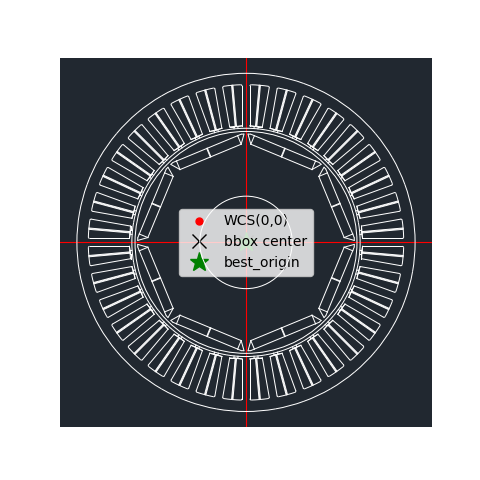

[classify_inner_outer_rotor] concentric radii (6): [35.0, 82.0, 84.0, 86.4, 119.4, 128.0]
  airgap: r_inner=82.0000, r_outer=84.0000, gap=2.0000
  inner entities: 120,  outer entities: 764
  → 판별 결과: inner_rotor
[split_stator_rotor] motor_type=inner_rotor
  airgap: 82.0000 ~ 84.0000
  stator entities: 764,  rotor entities: 120
[group_identical_entities] 22 distinct shapes
  LINE_len3.214_ravg88.10                        x72
  ARC_r86.400_span4.0                            x72
  LINE_len1.500_ravg87.15                        x72
  LINE_len30.091_ravg103.33                      x72
  ARC_r1.000_span91.9                            x72
  ARC_r119.400_span3.1                           x72
  LINE_len31.132_ravg103.73                      x72
  LINE_len0.500_ravg88.17                        x72
  LINE_len9.404_ravg88.29                        x36
  LINE_len3.000_ravg87.90                        x36
  ARC_r128.000_span10.0                          x36
  ARC_r86.400_span2.0                     

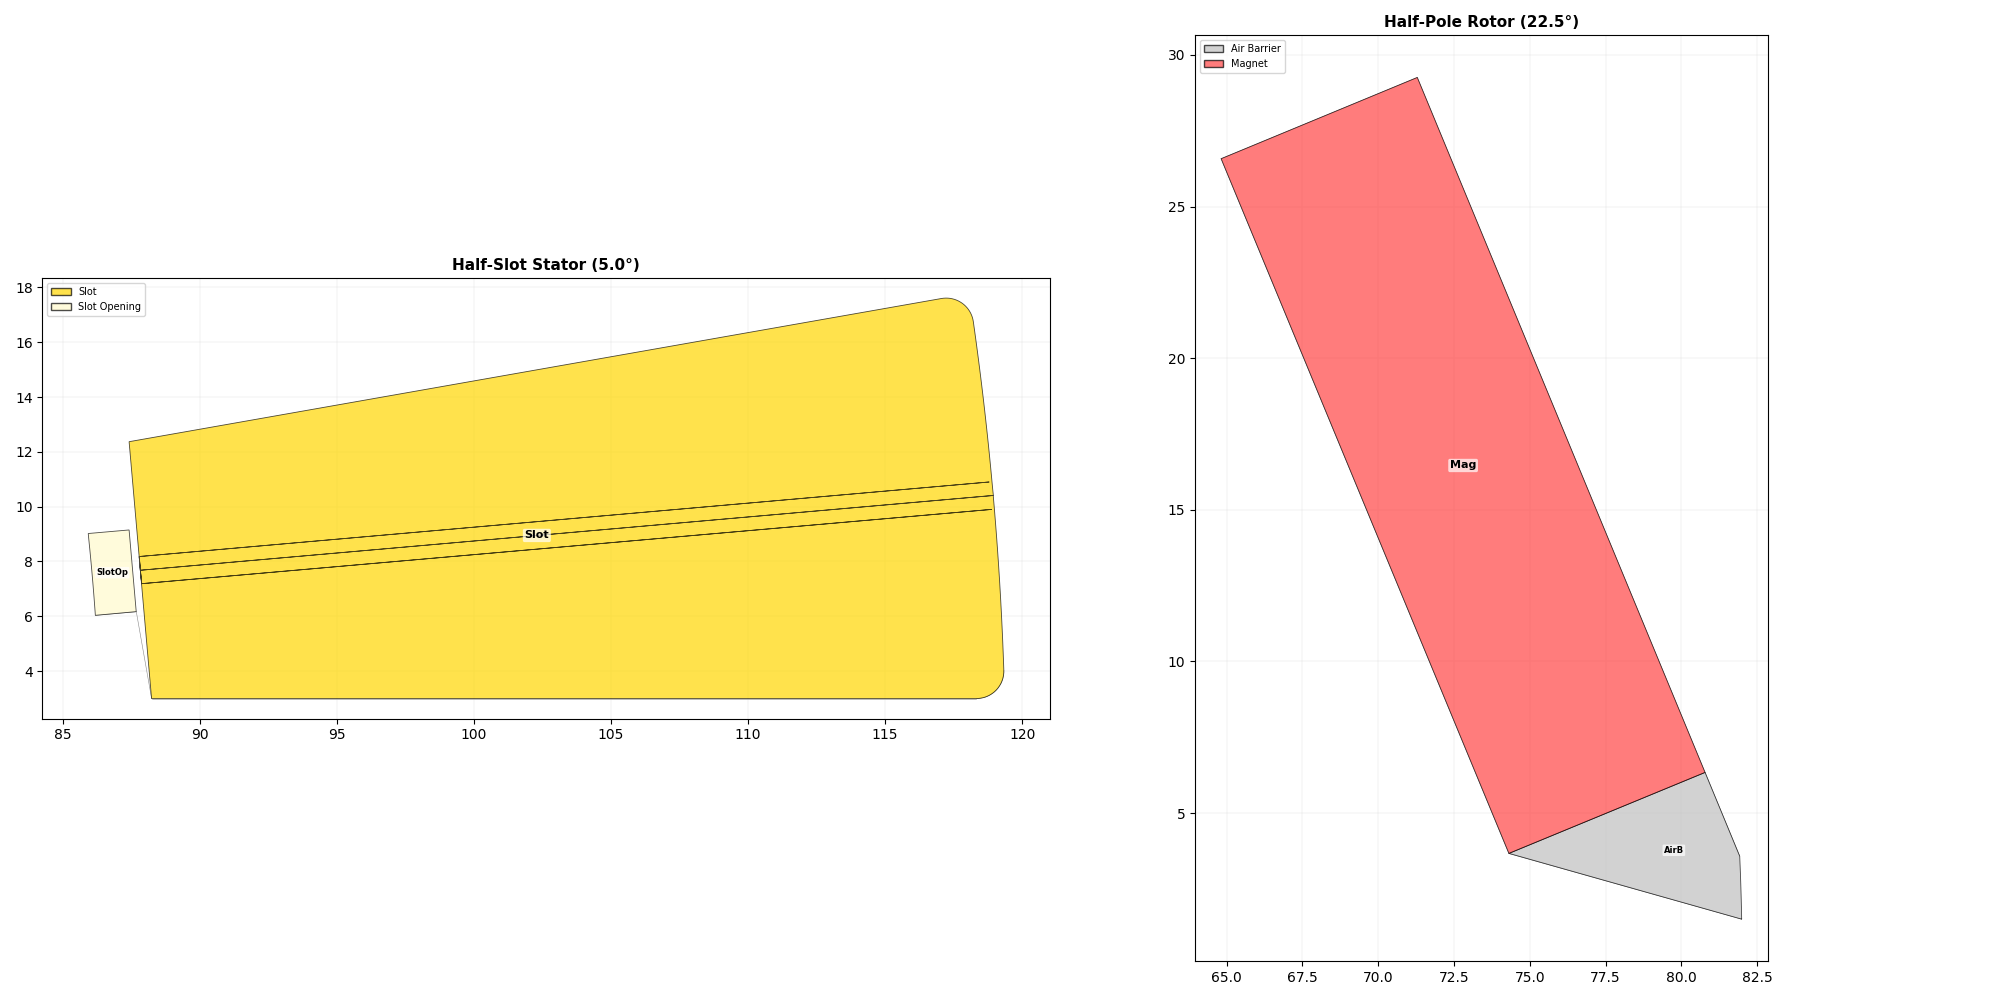

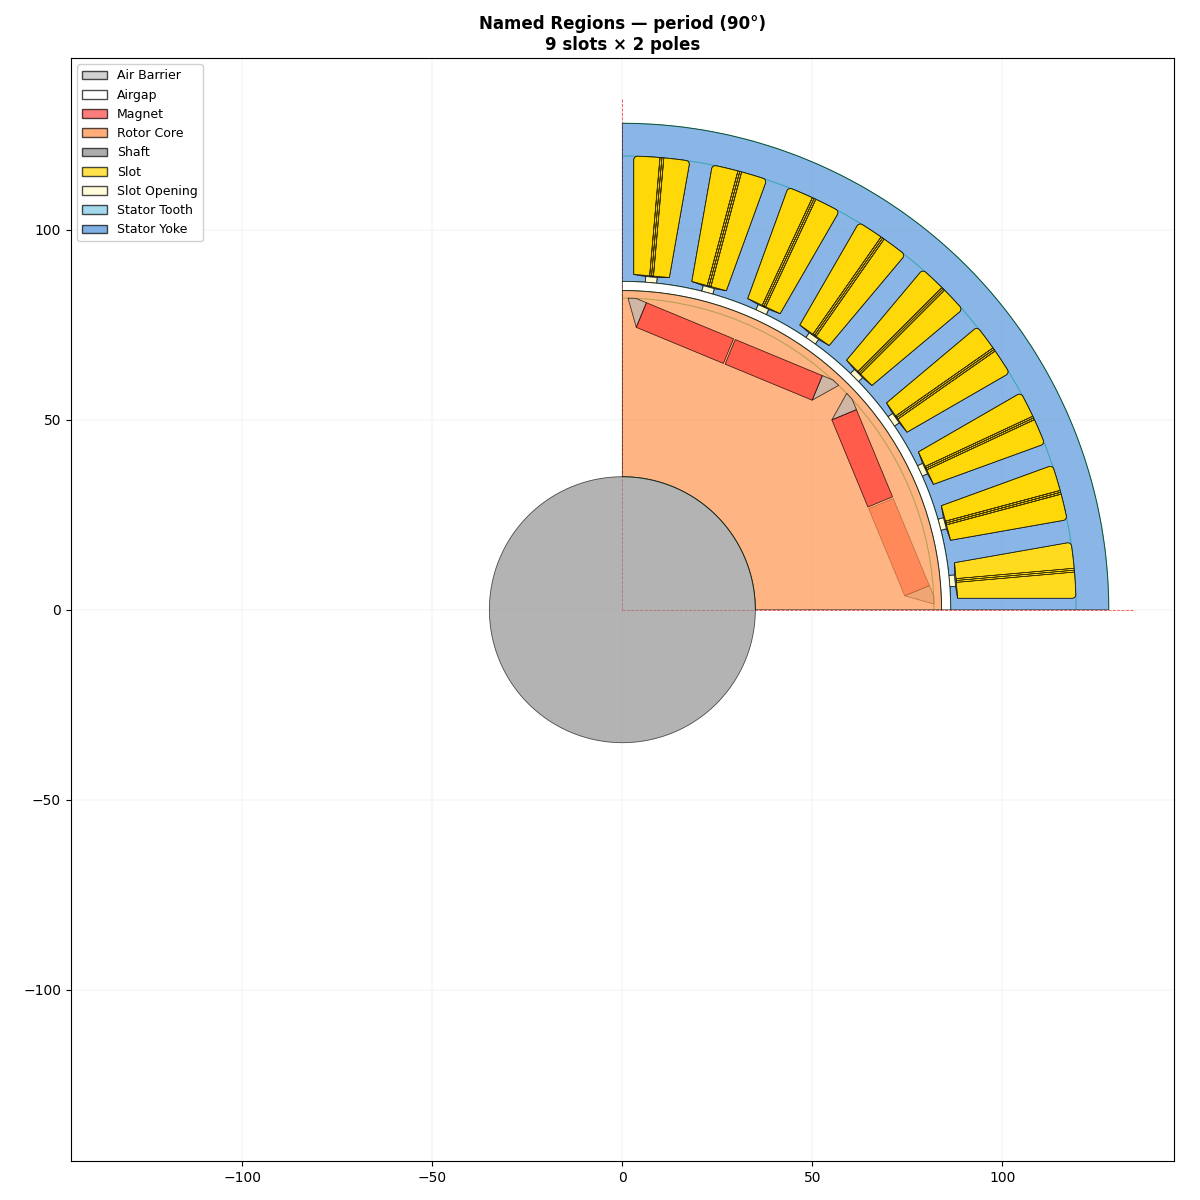

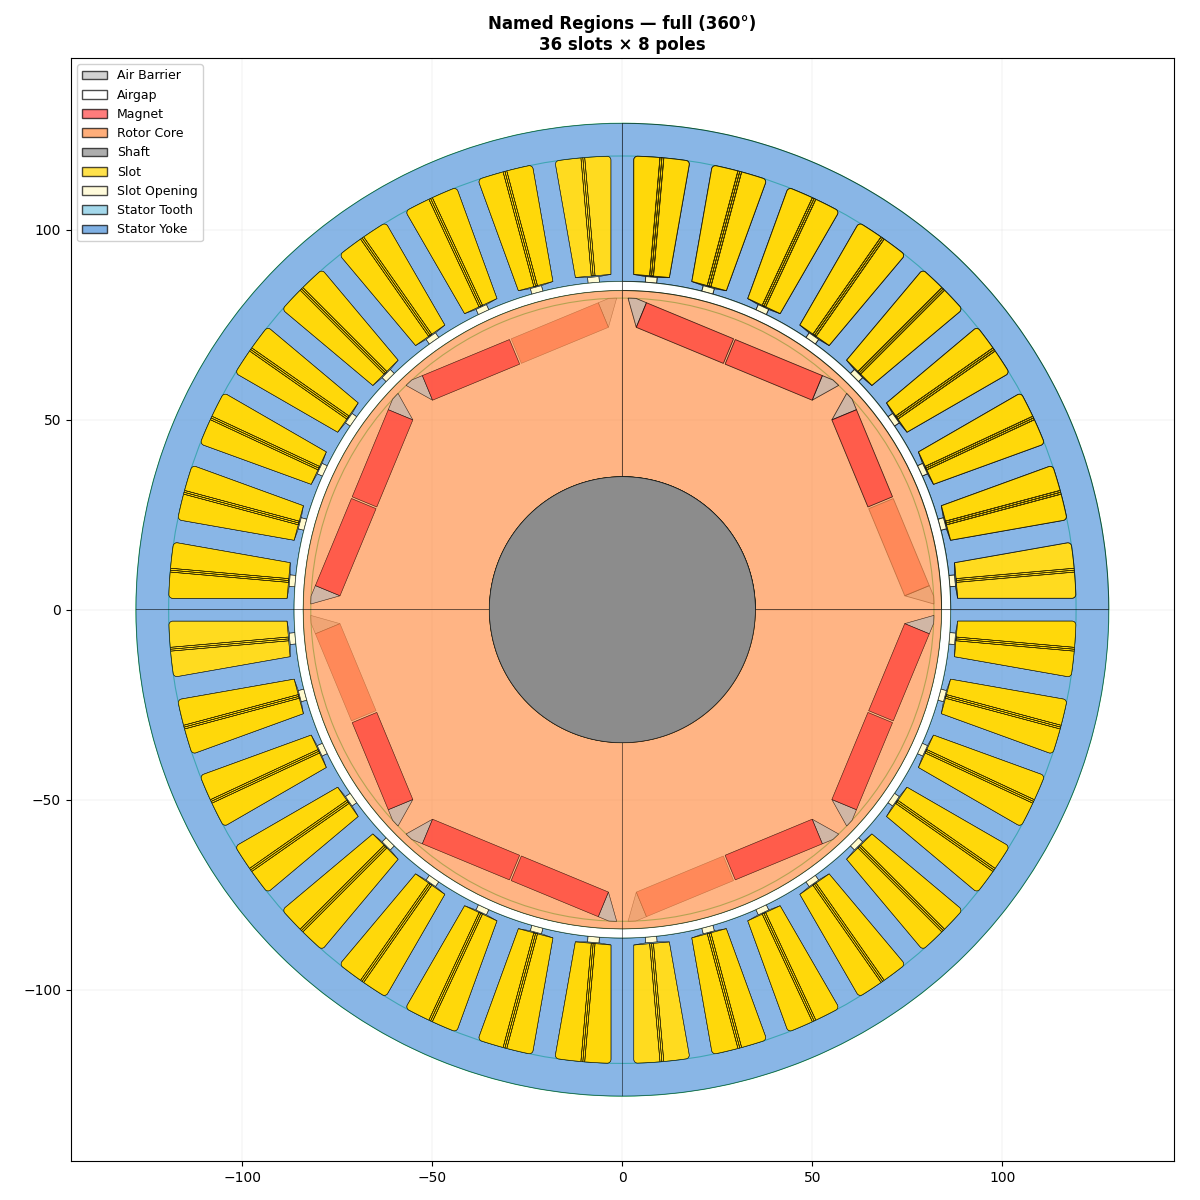

[extract_one_period] sector 0 (0.0°~90.0°): 407 entities

[find_closed_regions_in_period] sector 0 (0.0°~90.0°):
  Graph: V=419, E=417, Components=44
  Euler: F = E-V+C+1 = 417-419+44+1 = 43
  → graph regions (F-1): 42
  → independent circles: 0
  → total closed regions: 42
  [stator] regions=30  (V=359, E=359, C=30)
  [rotor]  regions=9  (V=56, E=48, C=17)

[Summary]
  Motor type     : inner_rotor
  Topology       : IPMSM  (n_layers=1, surface_ratio=0.67, span_ratio=0.11)
  Poles          : 8  (raw=16, circular=8, mirror=True)
  Slots          : 36  (raw=72, circular=36, mirror=True)
  Full model?    : True
  Period (deg)   : 90.0
  Can close rgn? : True
  Symmetry OK?   : True
  Closed regions : 42  (graph=42, circles=0)
    stator       : 30
    rotor        : 9

  [Named Regions (half-unit=4 + period-wide=35)]
    Slot Opening        : 9
    Slot                : 9
    Stator Tooth        : 9
    Air Barrier         : 4
    Magnet              : 4
    Stator Yoke         : 1
    Ai

In [13]:
# CELL-03: 전체 파이프라인 실행
result = analyze_motor_dxf(dxfPath, plot=True)

# 결과 요약 출력
ps = result['poles_slots']
print('\n' + '=' * 60)
print('[Summary]')
print(f"  Motor type     : {result['motor_type']}")
print(f"  Topology       : {result['topology']['topology']}  ({result['topology'].get('detail','')})")
print(f"  Poles          : {ps['n_poles']}  "
      f"(raw={ps['rotor_repeats_raw']}, circular={ps['rotor_repeats_circular']}, "
      f"mirror={ps['rotor_has_mirror']})")
print(f"  Slots          : {ps['n_slots']}  "
      f"(raw={ps['stator_repeats_raw']}, circular={ps['stator_repeats_circular']}, "
      f"mirror={ps['stator_has_mirror']})")
print(f"  Full model?    : {result['periodicity']['is_full_model']}")
print(f"  Period (deg)   : {result['periodicity']['period_deg']}")
print(f"  Can close rgn? : {result['closed_regions']['can_close_region']}")
print(f"  Symmetry OK?   : {result['closed_regions']['symmetry_ok']}")
if 'period_regions' in result:
    pr = result['period_regions']
    print(f"  Closed regions : {pr['n_closed_regions']}  "
          f"(graph={pr['n_graph_regions']}, circles={pr['n_circles']})")
    if pr['region_detail']:
        print(f"    stator       : {pr['region_detail']['stator_regions']}")
        print(f"    rotor        : {pr['region_detail']['rotor_regions']}")
if result.get('half_unit_regions'):
    hur = result['half_unit_regions']
    sf = hur['stator_faces']
    rf = hur['rotor_faces']
    from collections import Counter
    name_cnt = Counter(fi.get('name', 'unknown') for fi in sf + rf)
    n_half = sum(1 for fi in sf + rf if fi.get('scope') == 'half')
    n_period = sum(1 for fi in sf + rf if fi.get('scope') == 'period')
    print(f"\n  [Named Regions (half-unit={n_half} + period-wide={n_period})]")
    for name, cnt in name_cnt.most_common():
        print(f"    {REGION_NAMES.get(name, name):20s}: {cnt}")
if result.get('half_unit'):
    hu = result['half_unit']
    print(f"\n  [Half Unit (최소 반복 단위)]")
    print(f"    slot_pitch    : {hu['slot_pitch_deg']:.2f}° → half={hu['half_slot_deg']:.2f}°")
    print(f"    pole_pitch    : {hu['pole_pitch_deg']:.2f}° → half={hu['half_pole_deg']:.2f}°")
    print(f"    stator ents   : {len(hu['half_slot_stator'])}")
    print(f"    rotor ents    : {len(hu['half_pole_rotor'])}")
    print(f"    concentric    : {len(hu['concentric_circles'])}")
if result['symmetry_break']['broken_sectors']:
    print(f"  ⚠ Broken sectors: {len(result['symmetry_break']['broken_sectors'])}")
print('=' * 60)

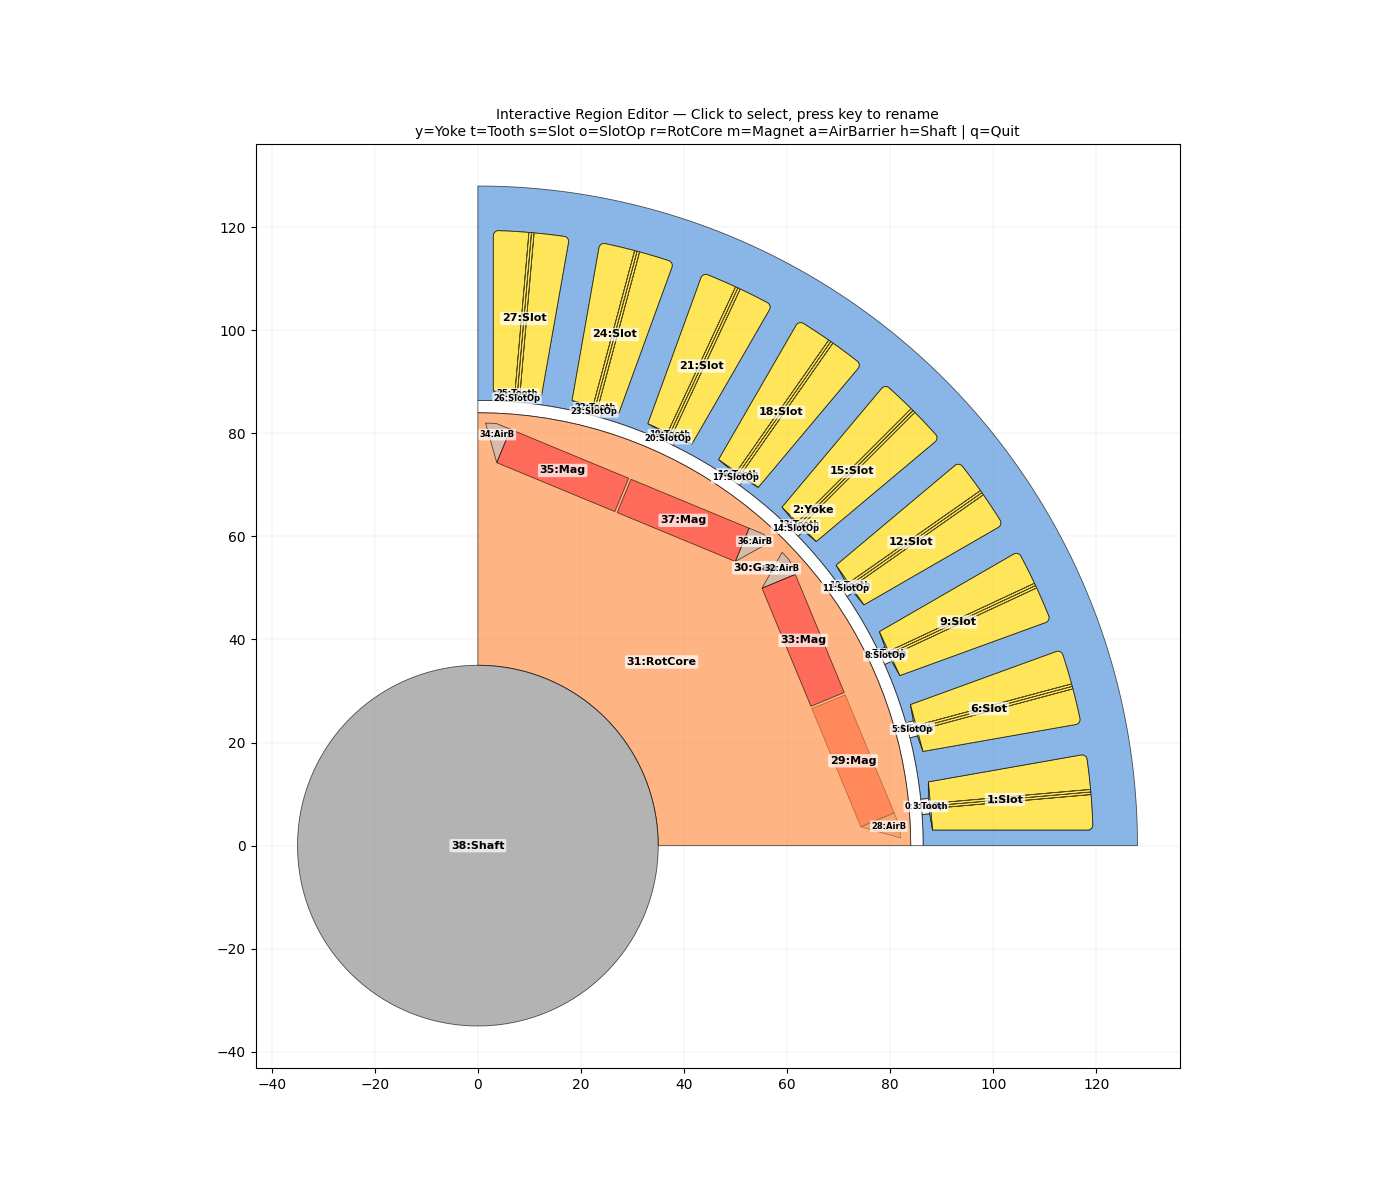

In [14]:
%matplotlib widget
# Interactive Region Editor — 클릭으로 영역 선택, 키보드로 이름 변경
# y=Yoke, t=Tooth, s=Slot, o=SlotOp, r=RotCore, m=Magnet, a=AirBarrier, h=Shaft
# p=병합, q=종료 (widget 백엔드에서는 GUI가 셀에 임베디드됩니다)
editor_state = interactive_region_editor(
    result['half_unit_regions'],
    result['half_unit'],
    result['split'],
    origin=result['origins']['best_origin']
)

In [15]:
# ▲ 위 셀의 GUI에서 영역 편집을 마친 뒤 이 셀을 실행하세요
edited_regions = finalize_region_editor(editor_state)


[finalize_region_editor] 편집 확정 완료
  id= 0  Slot Opening          area=     4.5
  id= 1  Slot                  area=   376.5
  id= 2  Stator Yoke           area=  3499.7
  id= 3  Stator Tooth          area=     1.7
  id= 4  Stator Tooth          area=     1.8
  id= 5  Slot Opening          area=     4.5
  id= 6  Slot                  area=   376.4
  id= 7  Stator Tooth          area=     1.7
  id= 8  Slot Opening          area=     4.5
  id= 9  Slot                  area=   376.5
  id=10  Stator Tooth          area=     1.8
  id=11  Slot Opening          area=     4.5
  id=12  Slot                  area=   376.4
  id=13  Stator Tooth          area=     1.8
  id=14  Slot Opening          area=     4.5
  id=15  Slot                  area=   376.5
  id=16  Stator Tooth          area=     1.8
  id=17  Slot Opening          area=     4.5
  id=18  Slot                  area=   376.4
  id=19  Stator Tooth          area=     1.7
  id=20  Slot Opening          area=     4.5
  id=21  Slot       

## Motor-CAD Adaptive Geometry 연동
DXF에서 인식한 `regions`를 Motor-CAD `Region` 객체로 변환 → `set_region()`으로 주입하여  
Adaptive Templates 스크립트에서 활용할 수 있도록 합니다.

**워크플로:**
1. **Cell 13 (변환)** — `faces_to_motorcad_regions()` → `mc_regions` 리스트 생성 + 요약 출력
2. **Cell 14 (주입)** — `apply_regions_to_motorcad()` → Motor-CAD에 `set_region()` 호출

In [22]:
# CELL-13: DXF regions → Motor-CAD Region 객체 변환
# edited_regions(GUI 편집 결과) 또는 result['half_unit_regions'](자동 분류 결과) 사용
mc_regions = faces_to_motorcad_regions(
    result,
    half_unit_regions=edited_regions,  # GUI에서 편집한 결과 반영
)

print(f"=== Motor-CAD Region 변환 결과: {len(mc_regions)}개 ===\n")
export_regions_summary(mc_regions)

=== Motor-CAD Region 변환 결과: 39개 ===

Name                                Type            Material      Dupl Scope   Closed  Ents
-----------------------------------------------------------------------------------------------
DXF_Stator Slot Opening_1           slot_opening    Air             36 half       Yes     4
DXF_Stator Slot_1                   slot            Air             36 half       Yes    17
DXF_Stator Lam (Back Iron)_1        stator_yoke     M19_29G          4 period     Yes   121
DXF_Stator Lam (Tooth)_1            stator_tooth    M19_29G          4 period     Yes     4
DXF_Stator Lam (Tooth)_2            stator_tooth    M19_29G          4 period     Yes     4
DXF_Stator Slot Opening_2           slot_opening    Air              4 period     Yes     4
DXF_Stator Slot_2                   slot            Air              4 period     Yes    17
DXF_Stator Lam (Tooth)_3            stator_tooth    M19_29G          4 period     Yes     4
DXF_Stator Slot Opening_3           slo

In [ ]:
# CELL-14: Motor-CAD에 regions 적용 (Motor-CAD가 실행 중이어야 합니다)
# ⚠ Motor-CAD를 먼저 실행하고, 대상 모델 파일을 열어둔 상태에서 실행하세요.
# ⚠ parent_stator_name / parent_rotor_name은 모델에 존재하는 region 이름이어야 합니다.

try:
    mc = apply_regions_to_motorcad(
        mc_regions,
        mc=None,                          # 새 연결 (기존 mc 인스턴스가 있으면 전달)
        open_new_instance=False,          # 이미 열린 Motor-CAD에 연결
        parent_stator_name='Stator',
        parent_rotor_name='Rotor',
    )
    print("\n✅ Motor-CAD Geometry Editor에서 regions를 확인하세요.")
except Exception as e:
    print(f"[연결 실패] {e}")
    print("- Motor-CAD를 실행한 뒤 다시 시도하세요")
    print("- 또는 open_new_instance=True로 새 인스턴스를 열어보세요")

## DXF 내보내기
인식된 영역을 원하는 범위로 DXF 파일로 내보냅니다.

**coverage 옵션:**
- `'half_slot'` / `'half_pole'` — 최소 반복 단위 (반슬롯/반극)
- `'slot'` / `'pole'` — 1슬롯 / 1극
- `'period'` — 한 주기 (예: 90°)
- `'full'` — 전체 360°

In [37]:
# CELL-15: ANSYS Maxwell용 DXF 내보내기
# 각 영역이 닫힌 폴리라인(LWPOLYLINE)으로 저장되어 Maxwell에서 바로 import 가능
# shaft는 내경=0인 부채꼴(pie sector)로 처리됨
import os

# 출력 폴더 설정 (원본 DXF와 같은 폴더)
output_dir = os.path.dirname(dxfPath)

# 주기 모델 (90°) - Maxwell용 (shaft가 1/4 부채꼴로 잘림)
export_regions_to_dxf_maxwell(
    result,
    half_unit_regions=edited_regions,
    output_path=os.path.join(output_dir, "maxwell_period_v4.dxf"),
    coverage='period',
    layer_by_name=True,
)


[export_regions_to_dxf_maxwell] ANSYS Maxwell용 DXF 내보내기 완료
  출력 파일  : E:\KDH\MoGen\maxwell_period_v4.dxf
  coverage   : period (90.0°)
  폴리라인 수: 79
  (각 영역이 닫힌 LWPOLYLINE으로 저장됨 - Maxwell import 가능)


'E:\\KDH\\MoGen\\maxwell_period_v4.dxf'